# Breast Tumor AI — Complete End-to-End Pipeline
### Stage 1 Detection → Segmentation Ensemble → Stage 3 Classification

| # | Section |
|---|---------|
| 1 | Imports & Configuration |
| 2 | Load All Models |
| 3 | Stage 1 — Tumor Detection Evaluation |
| 4 | Stage 3 — Benign vs Malignant Evaluation |
| 5 | Combined Training History |
| 6 | Core Pipeline + Tumour Feature Extraction |
| 7 | Segmentation Visualisation Suite |
| 8 | Full Single-Patient Pipeline *(V2 original — quick demo)* |
| 9 | Single Patient Visualisation *(specific or random — full seg vis)* |
| 10 | Batch Pipeline — All Test Patients |
| 11 | Per-Patient Results Table *(V2 original)* |
| 12 | Per-Patient Results Table — Extended *(all tumour metrics)* |
| 13 | Tumour Feature Distributions |
| 14 | Project Summary Card |


In [2]:
import os, sys, json, random, math, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from torch.amp import autocast
from torch.utils.data import DataLoader
from matplotlib.patches import Patch

try:
    from scipy import ndimage
    from scipy.ndimage import label as cc_label
    SCIPY_OK = True
except ImportError:
    SCIPY_OK = False
    print("[WARN] scipy not found — tumour count & surface area approximate")

# ── Project root ──────────────────────────────────────────────────
PROJECT_ROOT = r"D:\Breast_Tumor_AI_Project"
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification", "stage1"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification", "stage3"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "segmentation"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "segmentation_3d"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "dynunet_3d"))

# ── Paths ─────────────────────────────────────────────────────────
STAGE1_CKPT    = os.path.join(PROJECT_ROOT, "models", "classification_stage1",  "best_model_raw.pth")
STAGE3_CKPT    = os.path.join(PROJECT_ROOT, "models", "classification_stage3",  "best_model.pth")
SEG_MONAI_CKPT = os.path.join(PROJECT_ROOT, "models", "segmentation_3d",        "unet3d_best_raw.pth")
SEG_DYN_CKPT   = os.path.join(PROJECT_ROOT, "models", "dynunet_3d",             "dynunet_best_raw.pth")

for attr, alt in [("STAGE1_CKPT", "best_model.pth"), ("STAGE3_CKPT", "best_model.pth")]:
    if not os.path.isfile(eval(attr)):
        np2 = os.path.join(os.path.dirname(eval(attr)), alt)
        if os.path.isfile(np2): exec(f"{attr} = '{np2}'")

STAGE1_DATA = os.path.join(PROJECT_ROOT, "data", "classification_stage1")
STAGE3_DATA = os.path.join(PROJECT_ROOT, "data", "classification_stage3")
STAGE1_LOG  = os.path.join(PROJECT_ROOT, "models", "classification_stage1", "training_log.json")
STAGE3_LOG  = os.path.join(PROJECT_ROOT, "models", "classification_stage3", "training_log.json")

# ── Config ────────────────────────────────────────────────────────
THRESHOLD1 = 0.5
THRESHOLD3 = 0.5
VOXEL_MM3  = 1.5**3
VOXEL_SURF = 1.5**2
CROP_SIZE  = 64

# ── Colour palette ────────────────────────────────────────────────
BG     = "#0d1117"; CARD   = "#161b22"; BORDER = "#30363d"
TEXT   = "#c9d1d9"; MUTED  = "#8b949e"
BLUE   = "#3b82f6"; GREEN  = "#10b981"; AMBER  = "#f59e0b"
RED    = "#ef4444"; PURPLE = "#8b5cf6"
GT_COL = (0.2, 0.9, 0.2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

print("\nCheckpoints:")
for name, path in [("Stage 1", STAGE1_CKPT), ("Stage 3", STAGE3_CKPT),
                    ("Seg MONAI", SEG_MONAI_CKPT), ("Seg DynUNet", SEG_DYN_CKPT)]:
    print(f"  {'✓' if os.path.isfile(path) else '✗ MISSING':14s} {name:14s} {os.path.basename(path)}")


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Checkpoints:
  ✓              Stage 1        best_model_raw.pth
  ✓              Stage 3        best_model.pth
  ✓              Seg MONAI      unet3d_best_raw.pth
  ✓              Seg DynUNet    dynunet_best_raw.pth


## 1. Load All Models

In [3]:
import inspect
import model_dynunet

print("Functions in model_dynunet.py:")
for name, obj in inspect.getmembers(model_dynunet):
    if inspect.isfunction(obj) and not name.startswith("_"):
        print(f"  {name}")

print()
print("Classes in model_dynunet.py:")
for name, obj in inspect.getmembers(model_dynunet):
    if inspect.isclass(obj):
        print(f"  {name}")

Functions in model_dynunet.py:
  get_dynunet

Classes in model_dynunet.py:
  DynUNet


In [4]:
# ── Stage 1 model ─────────────────────────────────────────────────
try:
    from dataset_stage1 import FIXED_SIZE
    from model_stage1   import build_model as build_stage1
    model_s1 = build_stage1()
    ckpt1 = torch.load(STAGE1_CKPT, map_location=device, weights_only=False)
    state1 = ckpt1.get("model_state", ckpt1) if isinstance(ckpt1, dict) else ckpt1
    model_s1.load_state_dict(state1)
    model_s1 = model_s1.to(device).eval()
    ep1 = ckpt1.get("epoch", "?") if isinstance(ckpt1, dict) else "?"
    sc1 = ckpt1.get("best_score", "?") if isinstance(ckpt1, dict) else "?"
    print(f"  Stage 1 loaded  — epoch={ep1}  val_auc={sc1}")
    STAGE1_OK = True
except Exception as e:
    print(f"  Stage 1 FAILED: {e}")
    model_s1 = None; STAGE1_OK = False

# ── Stage 3 model ─────────────────────────────────────────────────
try:
    from data_stage3  import Stage3Dataset, STAGE3_ROOT, CROP_SIZE
    from model_stage3 import get_model_stage3
    model_s3 = get_model_stage3(device)
    ckpt3 = torch.load(STAGE3_CKPT, map_location=device, weights_only=False)
    state3 = ckpt3.get("model_state", ckpt3) if isinstance(ckpt3, dict) else ckpt3
    model_s3.load_state_dict(state3)
    model_s3 = model_s3.to(device).eval()
    ep3 = ckpt3.get("epoch", "?") if isinstance(ckpt3, dict) else "?"
    sc3 = ckpt3.get("best_score", "?") if isinstance(ckpt3, dict) else "?"
    print(f"  Stage 3 loaded  — epoch={ep3}  val_auc={sc3}")
    STAGE3_OK = True
except Exception as e:
    print(f"  Stage 3 FAILED: {e}")
    model_s3 = None; STAGE3_OK = False



# ── Segmentation ensemble models ──────────────────────────────────
# Tries to load model_3d.py (MONAI UNet3D) and model_dynunet.py (DynUNet).
# Both live in src/segmentation_3d/ which is already on sys.path.
SEG_OK      = False
model_monai = None
model_dyn   = None

try:
    from model_3d      import get_model as _get_monai
    from model_dynunet import get_dynunet as _get_dyn

    # ── MONAI UNet3D ──────────────────────────────────────────────
    # Try _raw.pth first (best single-epoch), then plain .pth (smooth best)
    _monai_paths = [
        SEG_MONAI_CKPT,
        SEG_MONAI_CKPT.replace("_raw.pth", ".pth"),
        SEG_MONAI_CKPT.replace("_best_raw.pth", "_best.pth"),
    ]
    _monai_ckpt_path = next((p for p in _monai_paths if os.path.isfile(p)), None)
    if _monai_ckpt_path is None:
        raise FileNotFoundError(
            f"MONAI checkpoint not found. Tried:\n" +
            "\n".join(f"  {p}" for p in _monai_paths) +
            "\nCheck models/segmentation_3d/ for the correct filename."
        )
    model_monai = _get_monai()
    _ck_m = torch.load(_monai_ckpt_path, map_location=device, weights_only=False)
    _sm_m = _ck_m.get("model_state", _ck_m) if isinstance(_ck_m, dict) else _ck_m
    model_monai.load_state_dict(_sm_m)
    model_monai = model_monai.to(device).eval()
    print(f"  Seg MONAI   loaded  ✓  ({os.path.basename(_monai_ckpt_path)})")

    # ── DynUNet ───────────────────────────────────────────────────
    _dyn_paths = [
        SEG_DYN_CKPT,
        SEG_DYN_CKPT.replace("_raw.pth", ".pth"),
        SEG_DYN_CKPT.replace("_best_raw.pth", "_best.pth"),
    ]
    _dyn_ckpt_path = next((p for p in _dyn_paths if os.path.isfile(p)), None)
    if _dyn_ckpt_path is None:
        raise FileNotFoundError(
            f"DynUNet checkpoint not found. Tried:\n" +
            "\n".join(f"  {p}" for p in _dyn_paths) +
            "\nCheck models/dynunet_3d/ for the correct filename."
        )
    model_dyn = _get_dyn()
    _ck_d = torch.load(_dyn_ckpt_path, map_location=device, weights_only=False)
    _sm_d = _ck_d.get("model_state", _ck_d) if isinstance(_ck_d, dict) else _ck_d
    model_dyn.load_state_dict(_sm_d)
    model_dyn = model_dyn.to(device).eval()
    print(f"  Seg DynUNet loaded  ✓  ({os.path.basename(_dyn_ckpt_path)})")

    SEG_OK = True

except Exception as _seg_err:
    print(f"\n  ✗ Segmentation models FAILED to load:")
    print(f"    {_seg_err}")
    print()
    print("  What this means in the pipeline:")
    print("  - Dice will show '—' (N/A) — no prediction computed")
    print("  - vis_3d_mip_filled will show GT only (green), NO red overlay")
    print("  - All other pipeline stages (S1, S3, metrics) still work normally")
    print()
    print("  To fix: check the paths printed above and rename your checkpoint files to match.")

print("\nAll models loaded.")

  Stage1 ResNet3D+CBAM: 33.4M parameters
  Stage 1 loaded  — epoch=49  val_auc=0.916
  Stage3 Model : 3D EfficientNet-B0 (MONAI) — 4.7M params
  Output bias  : 0.0000  (neutral 50/50 prior — loss corrects via pos_weight=0.403)
  Stage 3 loaded  — epoch=45  val_auc=0.92
  Output bias layer : model.2.1.conv.unit0.conv.bias
  Output bias init  : -7.6004  (sigmoid = 0.00050  ≈ tumor prevalence)
Model : MONAI ResNet UNet 3D
  spatial_dims  : 3
  in_channels   : 3  (P1, P2, P3)
  channels      : (32, 64, 128, 256, 320)
  strides       : (2, 2, 2, 2)
  num_res_units : 2
  norm          : instance
  dropout       : 0.1
  Total params  : 12,865,085
  Trainable     : 12,865,085
  Device        : cuda
  Seg MONAI   loaded  ✓  (unet3d_best_raw.pth)
  Output bias layer : output_block.conv.conv.bias
  Output bias init  : -7.6004  (sigmoid = 0.00050  ≈ tumour prevalence)
Model : DynUNet 3D (deep supervision)
  Total params     : 16,665,443
  Trainable        : 16,665,443
  Device           : cuda
  S

## 2. Stage 1 — Tumor Detection Evaluation

  Stage1Dataset [test ]:  89 patients  pos=54  neg=35

Stage1Dataset [test]: 89 patients  pos=54  neg=35
Stage 1 — Tumor Detection (test set, n=89)
AUC=0.8765  Acc=0.8202  F1=0.8333
Sensitivity=0.7407  Specificity=0.9429
TN=33 FP=2 FN=14 TP=40
Missed tumors : 14  False alarms : 2


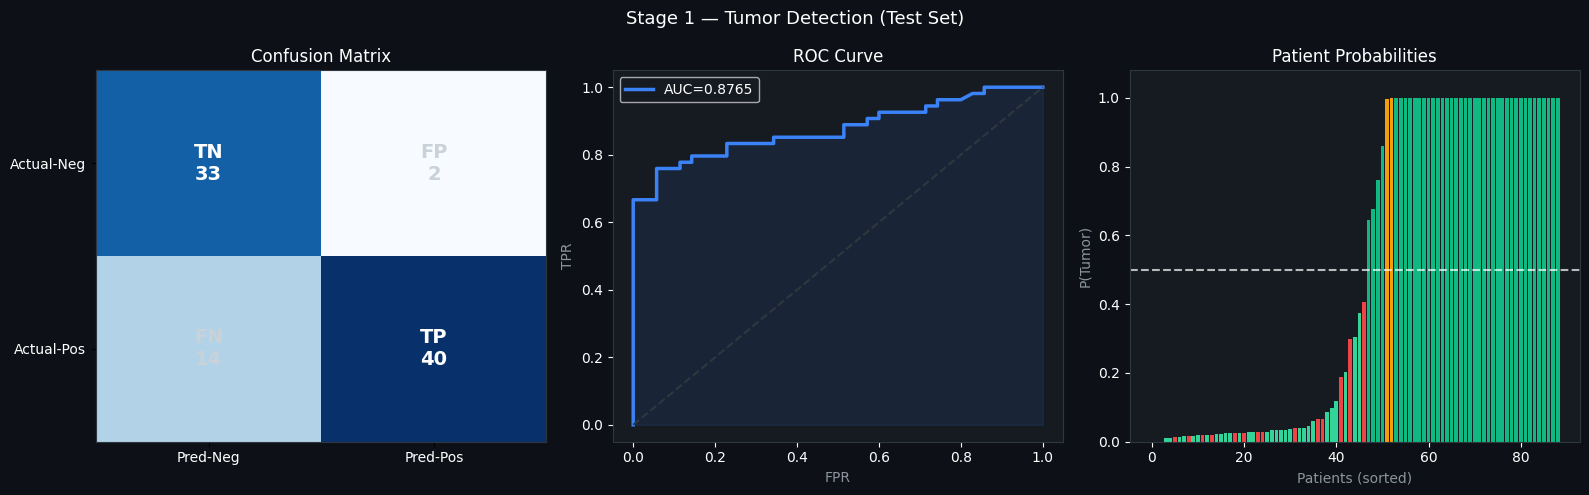

In [5]:
try:
    from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

if not STAGE1_OK:
    print("Stage 1 model not loaded — skipping")
else:
    from dataset_stage1 import Stage1Dataset

    test_ds1 = Stage1Dataset(STAGE1_DATA, "test", augment=False, fixed_size=FIXED_SIZE)
    loader1  = DataLoader(test_ds1, batch_size=1, shuffle=False, num_workers=0)

    labels1_all, probs1_all, pids1_all = [], [], []
    model_s1.eval()

    with torch.no_grad():
        for batch in loader1:
            img = batch["image"].to(device)
            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logit = model_s1(img)

            prob = float(torch.sigmoid(logit).cpu().item())
            lab  = int(batch["label"].item())
            pid  = os.path.basename(os.path.dirname(batch["path"][0]))

            labels1_all.append(lab)
            probs1_all.append(prob)
            pids1_all.append(pid)

    labels1_all = np.array(labels1_all)
    probs1_all  = np.array(probs1_all)
    preds1_all  = (probs1_all >= THRESHOLD1).astype(int)

    if SKLEARN_OK and len(set(labels1_all)) > 1:

        # ===== METRICS =====
        auc1  = float(roc_auc_score(labels1_all, probs1_all))
        acc1  = float((preds1_all == labels1_all).mean())
        f1_1  = float(f1_score(labels1_all, preds1_all, zero_division=0))
        cm1   = confusion_matrix(labels1_all, preds1_all, labels=[0,1])
        tn1, fp1, fn1, tp1 = cm1.ravel()

        sens1 = float(tp1/(tp1+fn1)) if (tp1+fn1) else 0
        spec1 = float(tn1/(tn1+fp1)) if (tn1+fp1) else 0

        # ===== PRINT SUMMARY (FROM FIRST CODE) =====
        print(f"\nStage1Dataset [test]: {len(labels1_all)} patients  pos={labels1_all.sum()}  neg={(labels1_all==0).sum()}")
        print(f"Stage 1 — Tumor Detection (test set, n={len(labels1_all)})")
        print(f"AUC={auc1:.4f}  Acc={acc1:.4f}  F1={f1_1:.4f}")
        print(f"Sensitivity={sens1:.4f}  Specificity={spec1:.4f}")
        print(f"TN={tn1} FP={fp1} FN={fn1} TP={tp1}")
        print(f"Missed tumors : {fn1}  False alarms : {fp1}")

        # ===== VISUALIZATION (FROM SECOND CODE) =====
        fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
        fig.suptitle("Stage 1 — Tumor Detection (Test Set)", color="white", fontsize=13)

        # --- Confusion Matrix ---
        ax = axes[0]; ax.set_facecolor(CARD)
        cm_v = np.array([[tn1,fp1],[fn1,tp1]])
        ax.imshow(cm_v, cmap="Blues", aspect="auto")

        labels_cm = [["TN","FP"],["FN","TP"]]
        for i in range(2):
            for j in range(2):
                ax.text(j,i,f"{labels_cm[i][j]}\n{cm_v[i,j]}",
                        ha="center", va="center",
                        color="white" if cm_v[i,j]>cm_v.max()*0.5 else TEXT,
                        fontsize=14, fontweight="bold")

        ax.set_xticks([0,1]); ax.set_xticklabels(["Pred-Neg","Pred-Pos"], color="white")
        ax.set_yticks([0,1]); ax.set_yticklabels(["Actual-Neg","Actual-Pos"], color="white")
        ax.set_title("Confusion Matrix", color="white")
        ax.spines[:].set_color(BORDER)

        # --- ROC Curve ---
        ax = axes[1]; ax.set_facecolor(CARD)
        fpr1, tpr1, _ = roc_curve(labels1_all, probs1_all)
        ax.plot(fpr1, tpr1, color=BLUE, lw=2.5, label=f"AUC={auc1:.4f}")
        ax.plot([0,1],[0,1], linestyle="--", color=BORDER)

        ax.fill_between(fpr1, tpr1, alpha=0.1, color=BLUE)
        ax.set_xlabel("FPR", color=MUTED)
        ax.set_ylabel("TPR", color=MUTED)
        ax.set_title("ROC Curve", color="white")
        ax.legend(facecolor=CARD, labelcolor="white")
        ax.tick_params(colors="white")
        ax.spines[:].set_color(BORDER)

        # --- Patient Probabilities ---
        ax = axes[2]; ax.set_facecolor(CARD)
        sidx = np.argsort(probs1_all)

        bar_col = []
        for p, l in zip(probs1_all[sidx], labels1_all[sidx]):
            pred = int(p >= THRESHOLD1)
            if pred == l:
                bar_col.append(GREEN if l==1 else "#34d399")
            else:
                bar_col.append(RED if l==1 else AMBER)

        ax.bar(range(len(sidx)), probs1_all[sidx],
               color=bar_col, width=0.8, edgecolor="none")

        ax.axhline(THRESHOLD1, color="white", linestyle="--", lw=1.5, alpha=0.7)
        ax.set_xlabel("Patients (sorted)", color=MUTED)
        ax.set_ylabel("P(Tumor)", color=MUTED)
        ax.set_title("Patient Probabilities", color="white")
        ax.tick_params(colors="white")
        ax.spines[:].set_color(BORDER)
        ax.set_ylim(0,1.08)

        plt.tight_layout()
        plt.savefig("stage1_eval.png", dpi=130, bbox_inches="tight", facecolor=BG)
        plt.show()

    else:
        print("⚠️ Not enough class diversity for metrics.")

## 3. Stage 3 — Benign vs Malignant Evaluation

  Stage3Dataset [test ]:  79 patients  mal=54  ben=25

Stage3Dataset [test]: 79 patients  mal=54.0  ben=25
Stage 3 — Benign vs Malignant (test set, n=79)
AUC=0.9200  Acc=0.8481  F1=0.8889
Sensitivity=0.8889  Specificity=0.7600  Precision=0.8889
TN=19 FP=6 FN=6 TP=48


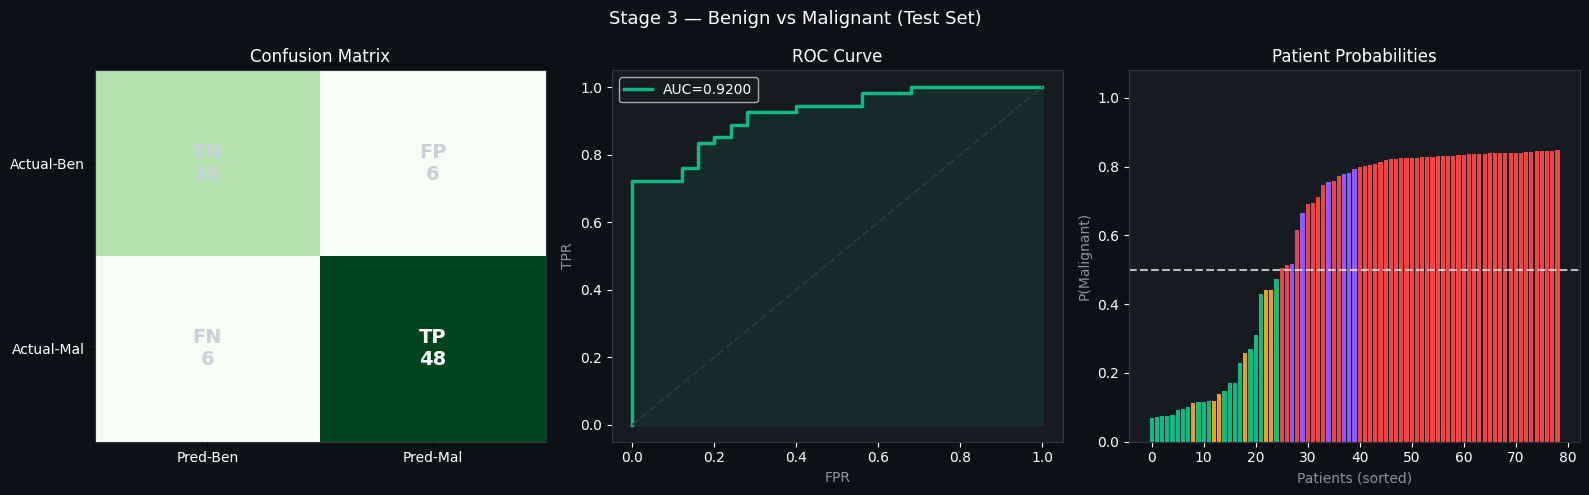

In [6]:
try:
    from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

if not STAGE3_OK:
    print("Stage 3 model not loaded — skipping")
else:
    test_ds3 = Stage3Dataset(STAGE3_DATA, "test", augment=False, crop_size=CROP_SIZE)
    loader3  = DataLoader(test_ds3, batch_size=8, shuffle=False, num_workers=0)

    labels3_all, probs3_all, pids3_all = [], [], []
    offset = 0

    model_s3.eval()
    with torch.no_grad():
        for images, labels in loader3:
            images = images.to(device)

            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logits = model_s3(images)

            probs = torch.sigmoid(logits).cpu().numpy().ravel()

            for j in range(len(probs)):
                idx = offset + j
                pid = (os.path.basename(os.path.dirname(test_ds3.samples[idx][0]))
                       if idx < len(test_ds3.samples) else str(idx))
                pids3_all.append(pid)

            offset += len(probs)
            labels3_all.extend(labels.numpy().ravel().tolist())
            probs3_all.extend(probs.tolist())

    labels3_all = np.array(labels3_all)
    probs3_all  = np.array(probs3_all)
    preds3_all  = (probs3_all >= THRESHOLD3).astype(int)

    if SKLEARN_OK and len(set(labels3_all)) > 1:

        # ===== METRICS =====
        auc3  = float(roc_auc_score(labels3_all, probs3_all))
        acc3  = float((preds3_all == labels3_all).mean())
        f1_3  = float(f1_score(labels3_all, preds3_all, zero_division=0))
        cm3   = confusion_matrix(labels3_all, preds3_all, labels=[0,1])
        tn3, fp3, fn3, tp3 = cm3.ravel()

        sens3 = float(tp3/(tp3+fn3)) if (tp3+fn3) else 0
        spec3 = float(tn3/(tn3+fp3)) if (tn3+fp3) else 0
        ppv3  = float(tp3/(tp3+fp3)) if (tp3+fp3) else 0

        # ===== PRINT SUMMARY =====
        print(f"\nStage3Dataset [test]: {len(labels3_all)} patients  mal={labels3_all.sum()}  ben={(labels3_all==0).sum()}")
        print(f"Stage 3 — Benign vs Malignant (test set, n={len(labels3_all)})")
        print(f"AUC={auc3:.4f}  Acc={acc3:.4f}  F1={f1_3:.4f}")
        print(f"Sensitivity={sens3:.4f}  Specificity={spec3:.4f}  Precision={ppv3:.4f}")
        print(f"TN={tn3} FP={fp3} FN={fn3} TP={tp3}")

        # ===== VISUALIZATION =====
        fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
        fig.suptitle("Stage 3 — Benign vs Malignant (Test Set)", color="white", fontsize=13)

        # --- Confusion Matrix ---
        ax = axes[0]; ax.set_facecolor(CARD)
        cm_v3 = np.array([[tn3, fp3], [fn3, tp3]])
        ax.imshow(cm_v3, cmap="Greens", aspect="auto")

        labels_cm = [["TN","FP"],["FN","TP"]]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{labels_cm[i][j]}\n{cm_v3[i,j]}",
                        ha="center", va="center",
                        color="white" if cm_v3[i,j] > cm_v3.max()*0.5 else TEXT,
                        fontsize=14, fontweight="bold")

        ax.set_xticks([0,1]); ax.set_xticklabels(["Pred-Ben","Pred-Mal"], color="white")
        ax.set_yticks([0,1]); ax.set_yticklabels(["Actual-Ben","Actual-Mal"], color="white")
        ax.set_title("Confusion Matrix", color="white")
        ax.spines[:].set_color(BORDER)

        # --- ROC Curve ---
        ax = axes[1]; ax.set_facecolor(CARD)
        fpr3, tpr3, _ = roc_curve(labels3_all, probs3_all)

        ax.plot(fpr3, tpr3, color=GREEN, lw=2.5, label=f"AUC={auc3:.4f}")
        ax.plot([0,1],[0,1], linestyle="--", color=BORDER)
        ax.fill_between(fpr3, tpr3, alpha=0.1, color=GREEN)

        ax.set_xlabel("FPR", color=MUTED)
        ax.set_ylabel("TPR", color=MUTED)
        ax.set_title("ROC Curve", color="white")
        ax.legend(facecolor=CARD, labelcolor="white")
        ax.tick_params(colors="white")
        ax.spines[:].set_color(BORDER)

        # --- Patient Probabilities ---
        ax = axes[2]; ax.set_facecolor(CARD)
        sidx3 = np.argsort(probs3_all)

        bar_col3 = []
        for p, l in zip(probs3_all[sidx3], labels3_all[sidx3]):
            pred = int(p >= THRESHOLD3)
            if pred == l:
                bar_col3.append(RED if l==1 else GREEN)
            else:
                bar_col3.append(AMBER if l==1 else PURPLE)

        ax.bar(range(len(sidx3)), probs3_all[sidx3],
               color=bar_col3, width=0.8, edgecolor="none")

        ax.axhline(THRESHOLD3, color="white", linestyle="--", lw=1.5, alpha=0.7)
        ax.set_xlabel("Patients (sorted)", color=MUTED)
        ax.set_ylabel("P(Malignant)", color=MUTED)
        ax.set_title("Patient Probabilities", color="white")
        ax.tick_params(colors="white")
        ax.spines[:].set_color(BORDER)
        ax.set_ylim(0, 1.08)

        plt.tight_layout()
        plt.savefig("stage3_eval.png", dpi=130, bbox_inches="tight", facecolor=BG)
        plt.show()

    else:
        print("⚠️ Not enough class diversity for metrics.")

## 4. Combined Training History — All Stages

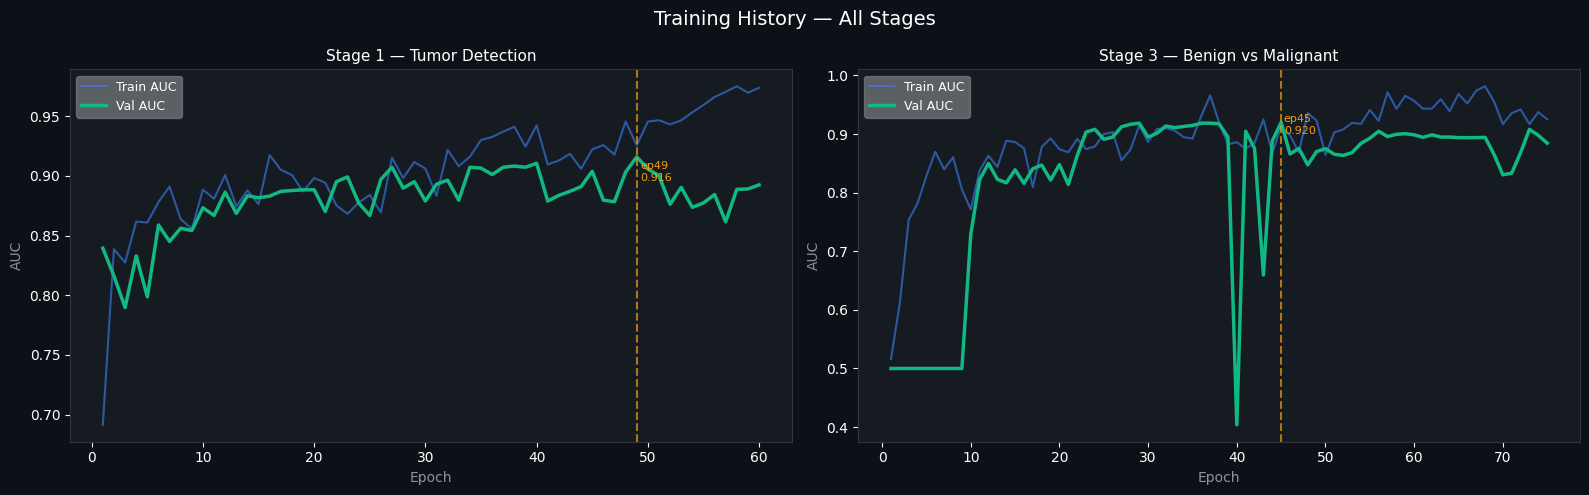

In [7]:
def _load_history(log_path):
    if not os.path.isfile(log_path): return {}
    with open(log_path) as f: log = json.load(f)
    h = {"val_auc": [], "train_auc": [], "val_loss": [], "train_loss": []}
    for row in log.get("history", []):
        for k in h:
            if k in row: h[k].append(row[k])
    return h

h1 = _load_history(STAGE1_LOG)
h3 = _load_history(STAGE3_LOG)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor="#0d1117")
fig.suptitle("Training History — All Stages", color="white", fontsize=14)

for ax, h, title in [(axes[0], h1, "Stage 1 — Tumor Detection"),
                      (axes[1], h3, "Stage 3 — Benign vs Malignant")]:
    ax.set_facecolor("#161b22")
    if h.get("val_auc"):
        ep = range(1, len(h["val_auc"])+1)
        if h.get("train_auc"): ax.plot(ep, h["train_auc"], color="#3b82f6", lw=1.5, alpha=0.6, label="Train AUC")
        ax.plot(ep, h["val_auc"], color="#10b981", lw=2.5, label="Val AUC")
        best_ep  = int(np.argmax(h["val_auc"]))+1
        best_auc = max(h["val_auc"])
        ax.axvline(best_ep, color="#f59e0b", lw=1.5, linestyle="--", alpha=0.7)
        ax.text(best_ep+0.3, best_auc-0.02, f"ep{best_ep}\n{best_auc:.3f}",
                color="#f59e0b", fontsize=8)
    ax.set_title(title, color="white", fontsize=11)
    ax.set_xlabel("Epoch", color="#8b949e")
    ax.set_ylabel("AUC", color="#8b949e")
    ax.tick_params(colors="white"); ax.spines[:].set_color("#30363d")
    ax.legend(fontsize=9, labelcolor="white", framealpha=0.3)

plt.tight_layout()
plt.savefig("pipeline_training_history.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 5. Core Pipeline Functions & Tumour Feature Extraction

In [8]:
# ─────────────────────────────────────────────────────────────────
# TUMOUR FEATURE EXTRACTION
# ─────────────────────────────────────────────────────────────────
def extract_tumour_features(img, lbl):
    """All metrics: geometry, DCE kinetics, texture, shape."""
    feat = {
        "voxels":0,"volume_mm3":0.0,"surface_area_mm2":0.0,
        "centroid":None,"bbox":None,"bbox_dims_mm":None,
        "sphericity":0.0,"compactness":0.0,"elongation":0.0,
        "tumour_count":0,
        "dce_means":[0.0,0.0,0.0],"enhancement_ratio":0.0,
        "washout_rate":0.0,"kinetic_type":"Unknown",
        "mean_intensity":0.0,"std_intensity":0.0,
        "min_intensity":0.0,"max_intensity":0.0,
        "contrast":0.0,"homogeneity":0.0,
        "t_stage":"Unknown","diameter_mm":0.0,
    }
    if lbl is None or lbl.sum()==0:
        return feat

    mask = (lbl[0]>0.5)
    vox  = int(mask.sum())
    vol  = round(vox*VOXEL_MM3,1)
    feat["voxels"]=vox; feat["volume_mm3"]=vol

    coords  = np.argwhere(mask)
    centroid= coords.mean(0).astype(int)
    feat["centroid"] = tuple(centroid.tolist())

    z0,y0,x0=coords.min(0); z1,y1,x1=coords.max(0)
    feat["bbox"]=(int(z0),int(y0),int(x0),int(z1),int(y1),int(x1))
    dz=(z1-z0+1)*1.5; dy=(y1-y0+1)*1.5; dx=(x1-x0+1)*1.5
    feat["bbox_dims_mm"]=(round(dz,1),round(dy,1),round(dx,1))
    feat["diameter_mm"]=round(max(dz,dy,dx),1)

    if SCIPY_OK:
        eroded=ndimage.binary_erosion(mask)
        feat["surface_area_mm2"]=round((vox-int(eroded.sum()))*VOXEL_SURF,1)
        _,n_comp=cc_label(mask); feat["tumour_count"]=int(n_comp)
    else:
        feat["surface_area_mm2"]=round(4.836*(vox**(2/3))*VOXEL_SURF,1)
        feat["tumour_count"]=1

    A=feat["surface_area_mm2"]
    if A>0: feat["sphericity"]=round(min(1.0,(math.pi**(1/3)*(6*vol)**(2/3))/A),4)
    bb_vol=max(1,(z1-z0+1)*(y1-y0+1)*(x1-x0+1))
    feat["compactness"]=round(vox/bb_vol,4)
    dims=sorted([z1-z0+1,y1-y0+1,x1-x0+1])
    feat["elongation"]=round(dims[2]/max(dims[0],1),3)

    means=[float(img[ch][mask].mean()) for ch in range(3)]
    feat["dce_means"]=[round(m,4) for m in means]
    er=round((means[1]-means[0])/max(abs(means[0]),1e-6),4)
    wr=round((means[1]-means[2])/max(abs(means[1]),1e-6),4)
    feat["enhancement_ratio"]=er; feat["washout_rate"]=wr
    if   means[2]<means[1]*0.9:  feat["kinetic_type"]="Washout — Type III ⚠"
    elif means[2]<means[1]*1.1:  feat["kinetic_type"]="Plateau — Type II"
    else:                          feat["kinetic_type"]="Persistent — Type I"

    px=img[1][mask]
    feat["mean_intensity"]=round(float(px.mean()),4)
    feat["std_intensity"] =round(float(px.std()),4)
    feat["min_intensity"] =round(float(px.min()),4)
    feat["max_intensity"] =round(float(px.max()),4)
    vr=feat["max_intensity"]-feat["min_intensity"]
    feat["contrast"]    =round(float(vr),4)
    feat["homogeneity"] =round(max(0.0,1.0-feat["std_intensity"]/max(vr,1e-6)),4)

    if   vol<500:    feat["t_stage"]="T1 (500–4 000 mm³)"
    elif vol<4000:   feat["t_stage"]="T1  (500–4 000 mm³)"
    elif vol<17000:  feat["t_stage"]="T2  (4–17 cm³)"
    else:            feat["t_stage"]="T3+ (>17 cm³)"

    return feat


# ─────────────────────────────────────────────────────────────────
# PATCH CROP  (for Stage 3 input)
# ─────────────────────────────────────────────────────────────────
def _crop_patch_np(img, label, crop_size=64):
    # FIX: use constant (zero) padding — reflect requires dim >= pad_width,
    # which fails on thin volumes and causes MemoryError.
    c = crop_size
    _, D, H, W = img.shape
    pD = max(0, c - D); pH = max(0, c - H); pW = max(0, c - W)
    if pD or pH or pW:
        img = np.pad(img,
                     ((0,0),(pD//2, pD-pD//2),(pH//2, pH-pH//2),(pW//2, pW-pW//2)),
                     mode="constant", constant_values=0)
    _, D, H, W = img.shape
    if label is not None and label.sum() > 0:
        c3 = np.argwhere(label[0] > 0.5).mean(0).astype(int)
    else:
        c3 = np.array([D//2, H//2, W//2])
    z = int(np.clip(c3[0], c//2, D-c//2))
    y = int(np.clip(c3[1], c//2, H-c//2))
    x = int(np.clip(c3[2], c//2, W-c//2))
    patch = img[:, z-c//2:z+c//2, y-c//2:y+c//2, x-c//2:x+c//2]
    if patch.shape != (3, c, c, c):
        patch = img[:, D//2-c//2:D//2+c//2,
                       H//2-c//2:H//2+c//2,
                       W//2-c//2:W//2+c//2]
    return patch

#####
def compute_dice(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt   = (gt > 0).astype(np.uint8)

    intersection = (pred & gt).sum()
    union = pred.sum() + gt.sum()

    return (2.0 * intersection / union) if union > 0 else 0.0
# ─────────────────────────────────────────────────────────────────
# MAIN PIPELINE  — stores img, lbl, feat in result dict
# (KeyError fix: result now always contains "img" and "lbl")
# ─────────────────────────────────────────────────────────────────
def run_full_pipeline(patient_dir, true_stage1_label=None,
                       true_stage3_label=None, verbose=True):

    pid      = os.path.basename(patient_dir)
    img_path = os.path.join(patient_dir, "image.npy")
    lbl_path = os.path.join(patient_dir, "label.npy")

    if not os.path.isfile(img_path):
        if verbose: print(f"  [SKIP] {pid} — image.npy not found")
        return None

    img = np.load(img_path).astype(np.float32)
    lbl = np.load(lbl_path).astype(np.float32) if os.path.isfile(lbl_path) else None

    result = {"patient_id": pid, "img": img, "lbl": lbl}

    # ── Stage 1 ────────────────────────────────────────────────────
    stage1_prob = None
    if STAGE1_OK:
        from monai.transforms import Compose, SpatialPadd, CenterSpatialCropd
        tf = Compose([
            SpatialPadd(keys=["image"], spatial_size=FIXED_SIZE, mode="constant", constant_values=0),
            CenterSpatialCropd(keys=["image"], roi_size=FIXED_SIZE),
        ])
        data = tf({"image": img})
        img_t = data["image"]
        if hasattr(img_t, "as_tensor"): img_t = img_t.as_tensor()
        img_t = img_t.float().unsqueeze(0).to(device)
        model_s1.eval()
        with torch.no_grad():
            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logit = model_s1(img_t)
        stage1_prob = float(torch.sigmoid(logit).cpu().item())

    result["stage1_prob"]  = round(stage1_prob, 4) if stage1_prob is not None else None
    result["stage1_pred"]  = int(stage1_prob >= THRESHOLD1) if stage1_prob is not None else None
    result["stage1_label"] = true_stage1_label

    # ── Feature extraction ─────────────────────────────────────────
    feat = extract_tumour_features(img, lbl)
    result["feat"] = feat

    result["tumor_voxels"]      = feat["voxels"]
    result["tumor_mm3"]         = feat["volume_mm3"]
    result["kinetic_type"]      = feat["kinetic_type"]
    result["enhancement_ratio"] = feat["enhancement_ratio"]

    # ── ENSEMBLE SEGMENTATION + DICE ───────────────────────────────
    # The seg models (MONAI UNet3D + DynUNet) were trained on volumes
    # preprocessed to (3, 128, 192, 192) by prepare_3d_offline.py.
    # We apply the same SpatialPadd + CenterSpatialCropd here so the
    # model receives the exact same shape it was trained on.
    # This also prevents OOM: raw patient volumes can be 300^3 which is
    # 810 MB on GPU — the cropped (3,128,192,192) tensor is only ~57 MB.
    pred_seg = None
    dice_val = None

    if SEG_OK and img is not None:
        try:
            from monai.transforms import Compose, SpatialPadd, CenterSpatialCropd
            _SEG_SPATIAL = (128, 192, 192)   # must match training in prepare_3d_offline.py
            _seg_tf = Compose([
                SpatialPadd(keys=["image"], spatial_size=_SEG_SPATIAL,
                            mode="constant", constant_values=0),
                CenterSpatialCropd(keys=["image"], roi_size=_SEG_SPATIAL),
            ])
            _seg_np  = _seg_tf({"image": img})["image"]
            if hasattr(_seg_np, "as_tensor"):
                _seg_np = _seg_np.as_tensor().float().numpy()
            _seg_np = np.ascontiguousarray(_seg_np)   # (3, 128, 192, 192)
            result["img_crop"] = _seg_np              # ← store for aligned viz
            # (1, 3, 128, 192, 192) on device
            _seg_in  = torch.from_numpy(_seg_np).unsqueeze(0).to(device)

            with torch.no_grad():
                with autocast(device_type=device.type, enabled=(device.type == "cuda")):
                    _prob_m = torch.sigmoid(model_monai(_seg_in)).cpu().numpy()[0]  # (1,128,192,192)
                    _prob_d = torch.sigmoid(model_dyn(_seg_in)).cpu().numpy()[0]

            del _seg_in          # free GPU memory immediately
            if device.type == "cuda":
                torch.cuda.empty_cache()

            _prob_ens = 0.35 * _prob_m + 0.65 * _prob_d   # Combination-C weights
            pred_seg  = (_prob_ens > 0.5).astype(np.float32)   # (1,128,192,192)

            # Dice: compare pred against GT (also cropped to same spatial size)
            if lbl is not None and lbl.sum() > 0:
                _lbl_tf   = Compose([
                    SpatialPadd(keys=["image"], spatial_size=_SEG_SPATIAL,
                                mode="constant", constant_values=0),
                    CenterSpatialCropd(keys=["image"], roi_size=_SEG_SPATIAL),
                ])
                _lbl_crop = _lbl_tf({"image": lbl})["image"]
                if hasattr(_lbl_crop, "as_tensor"):
                    _lbl_crop = _lbl_crop.as_tensor().float().numpy()
                _lbl_crop = np.ascontiguousarray(_lbl_crop)
                dice_val  = compute_dice(pred_seg, _lbl_crop)
                result["lbl_crop"] = _lbl_crop   # (1,128,192,192) — same as pred_seg

        except Exception as _seg_run_err:
            # ── IMPORTANT: do NOT fall back to lbl here ──────────────
            # Using lbl as pred_seg would show GT as the prediction,
            # making it look like the model ran when it did not.
            # pred_seg=None causes vis_3d_mip_filled to skip the red
            # overlay entirely and show a clear "model failed" message.
            print(f"  [SEG ERROR] Inference failed: {_seg_run_err}")
            print(f"  [SEG ERROR] Check: model weights, input shape, GPU memory")
            pred_seg = None   # do NOT use lbl — would show GT as prediction

    else:
        # Seg models not loaded — pred_seg stays None
        # vis_3d_mip_filled will show 'Seg models not loaded' message
        # Do NOT use lbl here: showing GT as red prediction is misleading.
        print(f"  [SEG] Models not loaded — no prediction available (SEG_OK=False)")
        pred_seg = None

    result["pred_seg"] = pred_seg
    result["dice"]     = dice_val

    # Mirror into feat["_dice"] so vis_mip + vis_3d_mip_filled show it in title
    feat["_dice"] = f"{dice_val:.4f}" if dice_val is not None else "—"
    # ──────────────────────────────────────────────────────────────

    # ── Stage 3 ───────────────────────────────────────────────────
    stage3_prob = None
    if STAGE3_OK:
        patch = _crop_patch_np(img, lbl, CROP_SIZE)
        patch = np.clip(patch, -3.5, 7.0)
        pt    = torch.from_numpy(patch).unsqueeze(0).to(device)
        model_s3.eval()
        with torch.no_grad():
            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logit = model_s3(pt)
        stage3_prob = float(torch.sigmoid(logit).cpu().item())

    result["stage3_prob"]  = round(stage3_prob, 4) if stage3_prob is not None else None
    result["stage3_pred"]  = int(stage3_prob >= THRESHOLD3) if stage3_prob is not None else None
    result["stage3_label"] = true_stage3_label

    # ── PRINT ─────────────────────────────────────────────────────
    if verbose:
        f = feat
        print(f"  Patient: {pid}")
        print(f"  Stage 1  : prob={result['stage1_prob']}  "
              f"→ {'TUMOR DETECTED' if result['stage1_pred'] else 'NO TUMOR'}")
        print(f"  Volume   : {f['volume_mm3']:.0f} mm³ ({f['voxels']} voxels)  |  {f['t_stage']}")
        print(f"  Centroid : {f['centroid']}  |  BBox: {f['bbox_dims_mm']} mm")
        print(f"  Surface  : {f['surface_area_mm2']} mm²  |  Sphericity: {f['sphericity']}")
        print(f"  Tumours  : {f['tumour_count']} component(s)  |  Elongation: {f['elongation']}")
        print(f"  Kinetic  : {f['kinetic_type']}  |  Enhancement: {f['enhancement_ratio']}")
        print(f"  Texture  : mean={f['mean_intensity']}  std={f['std_intensity']}  "
              f"contrast={f['contrast']}  homogeneity={f['homogeneity']}")

        # 🟢 PRINT DICE (ADDED)
        if result["dice"] is not None:
            print(f"  Dice     : {result['dice']:.4f}")
        else:
            print("  Dice     : N/A")

        print(f"  Stage 3  : prob={result['stage3_prob']}  "
              f"→ {'MALIGNANT' if result['stage3_pred'] else 'BENIGN'}")

        if true_stage3_label is not None:
            ok = result['stage3_pred'] == true_stage3_label
            print(f"  Correct  : {'✓' if ok else '✗'}  "
                  f"(true={['BENIGN','MALIGNANT'][true_stage3_label]})")

    return result


# ── Quick demo (matches V2 behaviour) ─────────────────────────────
demo_dir = os.path.join(STAGE3_DATA, "test", "malignant")
if os.path.isdir(demo_dir):
    demo_pid  = sorted(os.listdir(demo_dir))[0]
    demo_path = os.path.join(demo_dir, demo_pid)
    print(f"Running full pipeline on: {demo_pid}\n")
    demo_result = run_full_pipeline(demo_path, true_stage1_label=1, true_stage3_label=1)
else:
    demo_result = None
    print("Demo directory not found — edit demo_dir path.")

print("\nPipeline functions loaded.")


Running full pipeline on: 102

  Patient: 102
  Stage 1  : prob=1.0  → TUMOR DETECTED
  Volume   : 4388 mm³ (1300 voxels)  |  T2  (4–17 cm³)
  Centroid : (18, 97, 79)  |  BBox: (np.float64(18.0), np.float64(42.0), np.float64(42.0)) mm
  Surface  : 1662.8 mm²  |  Sphericity: 0.7795
  Tumours  : 6 component(s)  |  Elongation: 2.333
  Kinetic  : Plateau — Type II  |  Enhancement: 0.168
  Texture  : mean=4.7833  std=0.1749  contrast=2.0264  homogeneity=0.9137
  Dice     : 0.7203
  Stage 3  : prob=0.8276  → MALIGNANT
  Correct  : ✓  (true=MALIGNANT)

Pipeline functions loaded.


## 6. Segmentation Visualisation Suite
**Functions:** `vis_slice_overlay` · `vis_all_channels` · `vis_mip` · `vis_3d_mip_filled` · `vis_dce_kinetics` · `vis_feature_panel` · `visualise_segmentation_complete`

> Run Cell 5 first (loads `run_full_pipeline`). Call `visualise_segmentation_complete(result)` on any result dict.


In [9]:
# ─────────────────────────────────────────────────────────────────
# VIS A: Slice strip — GT contour + raw MRI below  (matches image 1)
# ─────────────────────────────────────────────────────────────────
def vis_slice_overlay(result, n_slices=5, channel=1, save=True):
    img = result["img"]       # (3,D,H,W)
    lbl = result["lbl"]       # (1,D,H,W) or None
    pid = result["patient_id"]
    f   = result.get("feat", {})
    D   = img.shape[1]

    cz = int(np.argwhere(lbl[0]>0.5).mean(0)[0]) if (lbl is not None and lbl.sum()>0) else D//2
    sl_idx = np.linspace(max(0,cz-n_slices*2), min(D-1,cz+n_slices*2), n_slices, dtype=int)
    cmap_ch = ["gray","gray","bone"][channel]
    ch_name = ["P1 (pre-contrast)","P2 (early post)","P3 (late post)"][channel]

    fig, axes = plt.subplots(2, n_slices, figsize=(n_slices*3.5, 7),
                              facecolor=BG, gridspec_kw={"hspace":0.04,"wspace":0.04})
    dice_str = f"  |  Dice={f.get('_dice','—')}" if f.get("_dice") else ""
    vox_str  = f"  |  GT voxels:{f.get('voxels','—'):,}  Vol:{f.get('volume_mm3','—')} mm³" if f.get("voxels") else ""
    fig.suptitle(f"Patient {pid}{dice_str}{vox_str}", color="white", fontsize=12, y=1.01)

    for si, sl in enumerate(sl_idx):
        ax = axes[0, si]; ax.set_facecolor("#000")
        slc = img[channel, sl]
        lo, hi = np.percentile(slc,[1,99]) if np.ptp(slc)>0 else (0,1)
        ax.imshow(slc, cmap=cmap_ch, vmin=lo, vmax=hi, aspect="equal")
        if lbl is not None and sl<lbl.shape[1] and lbl[0,sl].sum()>0:
            ax.contour(lbl[0,sl], levels=[0.5], colors=[GT_COL], linewidths=2.0)
        ax.set_title(f"Slice {sl}", color=MUTED, fontsize=8)
        if si==0: ax.set_ylabel(f"{ch_name}\n+ GT contour", color="white", fontsize=7)
        ax.axis("off")

        ax2 = axes[1, si]; ax2.set_facecolor("#000")
        ax2.imshow(slc, cmap="bone", vmin=lo, vmax=hi, aspect="equal")
        if si==0: ax2.set_ylabel("Raw MRI", color="white", fontsize=7)
        ax2.set_title(f"Slice {sl}", color=MUTED, fontsize=8)
        ax2.axis("off")

    gt_patch = mpatches.Patch(edgecolor=GT_COL, facecolor="none", label="GT tumour", linewidth=2)
    fig.legend(handles=[gt_patch], loc="lower right", facecolor=CARD, labelcolor="white", fontsize=9)
    plt.tight_layout()
    if save: plt.savefig(f"seg_slices_{pid}.png", dpi=130, bbox_inches="tight", facecolor=BG)
    plt.show()


# ─────────────────────────────────────────────────────────────────
# VIS B: All 3 DCE channels × n_slices with GT contour
# ─────────────────────────────────────────────────────────────────
def vis_all_channels(result, n_slices=5, save=True):
    img=result["img"]; lbl=result["lbl"]; pid=result["patient_id"]
    D=img.shape[1]
    cz=int(np.argwhere(lbl[0]>0.5).mean(0)[0]) if (lbl is not None and lbl.sum()>0) else D//2
    sl_idx=np.linspace(max(0,cz-n_slices*2),min(D-1,cz+n_slices*2),n_slices,dtype=int)
    cmaps=["gray","inferno","viridis"]
    ch_names=["P1 (pre-contrast)","P2 (early post-contrast)","P3 (late post-contrast)"]

    fig,axes=plt.subplots(3,n_slices,figsize=(n_slices*3.4,9),
                           facecolor=BG,gridspec_kw={"hspace":0.04,"wspace":0.04})
    fig.suptitle(f"DCE-MRI — All Channels: Patient {pid}", color="white", fontsize=13, y=1.01)
    for ch in range(3):
        for si,sl in enumerate(sl_idx):
            ax=axes[ch,si]; ax.set_facecolor("#000")
            slc=img[ch,sl]
            lo, hi = np.percentile(slc,[1,99]) if np.ptp(slc)>0 else (0,1)
            ax.imshow(slc,cmap=cmaps[ch],vmin=lo,vmax=hi,aspect="equal")
            if lbl is not None and sl<lbl.shape[1] and lbl[0,sl].sum()>0:
                ax.contour(lbl[0,sl],levels=[0.5],colors=[GT_COL],linewidths=1.8)
            if si==0: ax.set_ylabel(ch_names[ch],color="white",fontsize=8)
            if ch==0: ax.set_title(f"Slice {sl}",color=MUTED,fontsize=8)
            ax.axis("off")
    gt_patch=mpatches.Patch(edgecolor=GT_COL,facecolor="none",label="GT tumour",linewidth=2)
    fig.legend(handles=[gt_patch],loc="lower right",facecolor=CARD,labelcolor="white",fontsize=9)
    plt.tight_layout()
    if save: plt.savefig(f"seg_channels_{pid}.png",dpi=130,bbox_inches="tight",facecolor=BG)
    plt.show()


# ─────────────────────────────────────────────────────────────────
# VIS C: MIP across 3 axes — green fill  (matches image 2)
# ─────────────────────────────────────────────────────────────────
def vis_mip(result, save=True):
    img=result["img"]; lbl=result["lbl"]; pid=result["patient_id"]
    f=result.get("feat",{}); vol_ch=img[1]
    mips=[vol_ch.max(axis=0),vol_ch.max(axis=1),vol_ch.max(axis=2)]
    gts =([lbl[0].max(axis=0),lbl[0].max(axis=1),lbl[0].max(axis=2)]
          if lbl is not None else [None,None,None])
    titles=["Axial (D) — GT","Coronal (H) — GT","Sagittal (W) — GT"]
    dice_val=f.get("_dice","—")

    fig,axes=plt.subplots(1,3,figsize=(17,6),facecolor=BG)
    fig.suptitle(f"Max-Intensity Projection — Patient {pid}  |  Dice = {dice_val}",
                 color="black",fontsize=13,backgroundcolor="white")
    for ax,mip,gt,title in zip(axes,mips,gts,titles):
        lo,hi = np.percentile(mip,[1,99]) if np.ptp(mip)>0 else (0,1)
        ax.imshow(mip,cmap="gray",vmin=lo,vmax=hi,aspect="auto")
        if gt is not None and gt.max()>0:
            gt_rgba=np.zeros((*gt.shape,4),dtype=np.float32)
            gt_rgba[gt>0.5]=[0.2,0.85,0.2,0.55]
            ax.imshow(gt_rgba,aspect="auto")
        ax.set_title(title,fontsize=10,color="black"); ax.axis("off")
    gt_patch=mpatches.Patch(facecolor=(0.2,0.85,0.2,0.6),label="GT tumour")
    fig.legend(handles=[gt_patch],loc="lower center",facecolor="white",labelcolor="black",fontsize=10)
    plt.tight_layout()
    if save: plt.savefig(f"seg_mip_{pid}.png",dpi=130,bbox_inches="tight",facecolor=BG)
    plt.show()


# ─────────────────────────────────────────────────────────────────
# VIS D: 3D filled projection — dark-red fill  (matches image 3)
# ─────────────────────────────────────────────────────────────────
def vis_3d_mip_filled(result, save=True):
    img      = result["img"]
    lbl      = result["lbl"]              # GT mask — original full volume
    pred_seg = result.get("pred_seg")     # Ensemble prediction (1,128,192,192) or None
    pid      = result["patient_id"]
    f        = result.get("feat", {})
    dice_str = f.get("_dice", "—")

    # ── KEY FIX: use cropped arrays when available ─────────────────
    # pred_seg is (1,128,192,192) — cropped to SEG_SPATIAL during inference.
    # The MRI background and GT must use the same spatial size, otherwise
    # matplotlib stretches each imshow to fill the axes independently and
    # the overlays appear misaligned (red floats below the MRI on coronal/sagittal).
    # img_crop and lbl_crop are stored in result during seg inference.
    img_for_viz = result.get("img_crop", img)   # (3,128,192,192) or full
    lbl_for_viz = result.get("lbl_crop", lbl)   # (1,128,192,192) or full
    vol_ch      = img_for_viz[1]                 # P2 channel for background MIP

    ax_names = ["Axial   (D)", "Coronal (H)", "Sagittal(W)"]

    fig, axes = plt.subplots(1, 3, figsize=(17, 6), facecolor="white")
    title_line = (f"Ensemble Predicted Segmentation — Patient {pid}"
                  f"  |  Vol={f.get('volume_mm3','?')} mm³"
                  f"  |  {f.get('t_stage','')}"
                  f"  |  Dice = {dice_str}")
    fig.suptitle(title_line, color="black", fontsize=12)

    for axis_idx, (ax, ax_name) in enumerate(zip(axes, ax_names)):
        # ── MRI background (same crop as overlays) ────────────────
        mip = vol_ch.max(axis=axis_idx)
        lo, hi = (np.percentile(mip, [1, 99]) if np.ptp(mip) > 0 else (0, 1))
        ax.imshow(mip, cmap="gray", vmin=lo, vmax=hi, aspect="auto")

        # ── GT overlay — transparent green ────────────────────────
        # lbl_for_viz is same shape as pred_seg → aligns perfectly.
        if lbl_for_viz is not None:
            gt_proj = lbl_for_viz[0].max(axis=axis_idx)
            if gt_proj.max() > 0:
                gt_rgba = np.zeros((*gt_proj.shape, 4), dtype=np.float32)
                gt_rgba[gt_proj > 0.5] = [0.1, 0.85, 0.1, 0.35]
                ax.imshow(gt_rgba, aspect="auto")

        # ── Prediction overlay — solid red ────────────────────────
        # pred_seg is same shape as lbl_for_viz and vol_ch → aligns.
        if pred_seg is not None:
            ps_proj = pred_seg[0].max(axis=axis_idx)
            if ps_proj.max() > 0:
                ps_rgba = np.zeros((*ps_proj.shape, 4), dtype=np.float32)
                ps_rgba[ps_proj > 0.5] = [0.85, 0.08, 0.08, 0.80]
                ax.imshow(ps_rgba, aspect="auto")
        elif axis_idx == 1:
            ax.text(0.5, 0.05, "Seg model not loaded — no prediction",
                    transform=ax.transAxes, ha="center", va="center",
                    color="red", fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

        ax.set_title(ax_name, fontsize=10, color="black")
        ax.axis("off")

    legend_handles = []
    if lbl_for_viz is not None:
        legend_handles.append(mpatches.Patch(
            facecolor=(0.1, 0.85, 0.1, 0.5), label="GT tumour (green)"))
    if pred_seg is not None and SEG_OK:
        legend_handles.append(mpatches.Patch(
            facecolor=(0.85, 0.08, 0.08, 0.85), label="Ensemble prediction (red)"))
    elif pred_seg is None:
        legend_handles.append(mpatches.Patch(
            facecolor=(0.5, 0.5, 0.5, 0.5), label="Seg model not loaded — fix Cell 2"))
    if legend_handles:
        fig.legend(handles=legend_handles, loc="lower center",
                   facecolor="white", labelcolor="black", fontsize=10, ncol=2)

    plt.tight_layout()
    if save:
        plt.savefig(f"seg_3d_{pid}.png", dpi=130, bbox_inches="tight", facecolor=BG)
    plt.show()


# ─────────────────────────────────────────────────────────────────
# VIS E: DCE kinetics line plot
# ─────────────────────────────────────────────────────────────────
def vis_dce_kinetics(result, ax=None, save=False):
    f=result.get("feat",{}); pid=result["patient_id"]
    dm=f.get("dce_means",[0,0,0]); kin=f.get("kinetic_type","Unknown")
    standalone=(ax is None)
    if standalone: fig,ax=plt.subplots(figsize=(6,4),facecolor=BG)
    ax.set_facecolor(CARD)
    ax.plot([1,2,3],dm,"o-",color=BLUE,lw=2.5,ms=10,zorder=3)
    ax.fill_between([1,2,3],dm,alpha=0.15,color=BLUE)
    for xi,(yi,ci) in enumerate(zip(dm,[BLUE,GREEN,AMBER]),1):
        ax.scatter([xi],[yi],s=90,color=ci,zorder=4,edgecolors="white",lw=1)
        ax.text(xi,yi+max(dm)*0.04,f"{yi:.3f}",ha="center",color="white",fontsize=9,fontweight="bold")
    ax.set_xticks([1,2,3]); ax.set_xticklabels(["P1\n(pre)","P2\n(early)","P3\n(late)"],color="white",fontsize=10)
    ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
    ann_col=RED if "III" in kin else AMBER if "II" in kin else GREEN
    ax.set_title(f"DCE Kinetics: {kin}",color="white",fontsize=10)
    ax.set_ylabel("Mean intensity (tumour)",color=MUTED,fontsize=8)
    ax.text(2,min(dm)*0.92,kin,ha="center",color=ann_col,fontsize=8,fontweight="bold",style="italic")
    if standalone:
        plt.tight_layout()
        if save: plt.savefig(f"dce_{pid}.png",dpi=130,bbox_inches="tight",facecolor=BG)
        plt.show()


# ─────────────────────────────────────────────────────────────────
# VIS F: Feature panel — geometry, texture, kinetics, bbox, histogram, radar
# ─────────────────────────────────────────────────────────────────
def vis_feature_panel(result, save=True):
    f=result.get("feat",{}); pid=result["patient_id"]
    img=result["img"]; lbl=result["lbl"]

    fig=plt.figure(figsize=(18,9),facecolor=BG)
    fig.suptitle(f"Tumour Feature Report — Patient {pid}",color="white",fontsize=15,y=1.01,fontweight="bold")
    gs=gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.35)

    # Geometry
    ax1=fig.add_subplot(gs[0,0]); ax1.set_facecolor(CARD); ax1.axis("off")
    geom=[
        ("Volume",f"{f.get('volume_mm3',0):.1f} mm³"),
        ("Voxels",f"{f.get('voxels',0):,}"),
        ("Diameter",f"{f.get('diameter_mm',0):.1f} mm"),
        ("BBox (mm)",f"{f.get('bbox_dims_mm','—')}"),
        ("Centroid (z,y,x)",f"{f.get('centroid','—')}"),
        ("Surface area",f"{f.get('surface_area_mm2',0):.1f} mm²"),
        ("Sphericity",f"{f.get('sphericity',0):.4f}"),
        ("Compactness",f"{f.get('compactness',0):.4f}"),
        ("Elongation",f"{f.get('elongation',0):.3f}"),
        ("Tumour count",f"{f.get('tumour_count',0)} component(s)"),
        ("T-stage est.",f.get("t_stage","Unknown")),
    ]
    ax1.text(0.5,0.98,"Shape & Geometry",ha="center",color=AMBER,fontsize=11,fontweight="bold",transform=ax1.transAxes,va="top")
    for i,(k,v) in enumerate(geom):
        y=0.88-i*0.082
        ax1.text(0.02,y,k+":",color=MUTED,fontsize=9,transform=ax1.transAxes,va="center")
        ax1.text(0.98,y,v,color=TEXT,fontsize=9,transform=ax1.transAxes,va="center",ha="right")
        if i>0: ax1.axhline(y+0.04,color=BORDER,lw=0.4,xmin=0.01,xmax=0.99)

    # Texture
    ax2=fig.add_subplot(gs[0,1]); ax2.set_facecolor(CARD); ax2.axis("off")
    tex=[
        ("Mean intensity",f"{f.get('mean_intensity',0):.4f}"),
        ("Std intensity",f"{f.get('std_intensity',0):.4f}"),
        ("Min intensity",f"{f.get('min_intensity',0):.4f}"),
        ("Max intensity",f"{f.get('max_intensity',0):.4f}"),
        ("Contrast",f"{f.get('contrast',0):.4f}"),
        ("Homogeneity",f"{f.get('homogeneity',0):.4f}"),
        ("Enhancement",f"{f.get('enhancement_ratio',0):.4f}"),
        ("Washout rate",f"{f.get('washout_rate',0):.4f}"),
    ]
    ax2.text(0.5,0.98,"Intensity & Texture (P2)",ha="center",color=PURPLE,fontsize=11,fontweight="bold",transform=ax2.transAxes,va="top")
    for i,(k,v) in enumerate(tex):
        y=0.88-i*0.104
        ax2.text(0.02,y,k+":",color=MUTED,fontsize=9,transform=ax2.transAxes,va="center")
        ax2.text(0.98,y,v,color=TEXT,fontsize=9,transform=ax2.transAxes,va="center",ha="right")
        if i>0: ax2.axhline(y+0.05,color=BORDER,lw=0.4,xmin=0.01,xmax=0.99)

    # DCE kinetics
    ax3=fig.add_subplot(gs[0,2])
    vis_dce_kinetics(result, ax=ax3)

    # Axial MIP + BBox + centroid
    ax4=fig.add_subplot(gs[1,0]); ax4.set_facecolor("#000")
    mip=img[1].max(axis=0)
    lo,hi=np.percentile(mip,[1,99]) if np.ptp(mip)>0 else (0,1)
    ax4.imshow(mip,cmap="gray",vmin=lo,vmax=hi,aspect="auto")
    if lbl is not None:
        gp=lbl[0].max(axis=0)
        if gp.max()>0: ax4.contour(gp,levels=[0.5],colors=[GT_COL],linewidths=2)
    bb=f.get("bbox")
    if bb is not None:
        z0,y0,x0,z1,y1,x1=bb
        rect=mpatches.Rectangle((x0,y0),x1-x0,y1-y0,
                                  linewidth=2,edgecolor=AMBER,facecolor="none",linestyle="--")
        ax4.add_patch(rect)
        cent=f.get("centroid")
        if cent: ax4.scatter([cent[2]],[cent[1]],c=RED,s=80,zorder=5,marker="+",linewidths=2)
    ax4.set_title("Axial MIP + BBox + Centroid (+)",color="white",fontsize=9); ax4.axis("off")

    # Intensity histogram
    ax5=fig.add_subplot(gs[1,1]); ax5.set_facecolor(CARD)
    if lbl is not None and lbl.sum()>0:
        mask=(lbl[0]>0.5)
        for ch,col,lbl_ch in zip([0,1,2],[BLUE,GREEN,AMBER],["P1","P2","P3"]):
            ax5.hist(img[ch][mask],bins=40,color=col,alpha=0.6,label=lbl_ch,density=True)
        ax5.set_xlabel("Intensity",color=MUTED,fontsize=9)
        ax5.set_ylabel("Density",color=MUTED,fontsize=9)
        ax5.legend(facecolor=BG,labelcolor="white",fontsize=8)
    ax5.set_title("Intensity Histogram (mask)",color="white",fontsize=9)
    ax5.tick_params(colors="white"); ax5.spines[:].set_color(BORDER)

    # Radar chart
    ax6=fig.add_subplot(gs[1,2],polar=True); ax6.set_facecolor(CARD)
    labels_r=["Sphericity","Compactness","Homogeneity","Enhancement","Washout-inv"]
    vals_r=[min(1.0,f.get("sphericity",0)),min(1.0,f.get("compactness",0)),
            min(1.0,f.get("homogeneity",0)),min(1.0,abs(f.get("enhancement_ratio",0))/2.0),
            max(0.0,1.0-abs(f.get("washout_rate",0)))]
    N=len(labels_r)
    angles=[2*math.pi/N*i for i in range(N)]+[0]
    vals_p=vals_r+[vals_r[0]]
    ax6.plot(angles,vals_p,color=BLUE,lw=2)
    ax6.fill(angles,vals_p,color=BLUE,alpha=0.25)
    ax6.set_xticks(angles[:-1]); ax6.set_xticklabels(labels_r,color="white",fontsize=8)
    ax6.set_yticks([0.25,0.5,0.75,1.0]); ax6.set_yticklabels([])
    ax6.spines["polar"].set_color(BORDER); ax6.grid(color=BORDER,lw=0.7)
    ax6.set_facecolor(CARD); ax6.set_title("Shape Radar",color="white",fontsize=9,pad=12)

    plt.savefig(f"seg_features_{pid}.png",dpi=130,bbox_inches="tight",facecolor=BG)
    plt.show()


# ─────────────────────────────────────────────────────────────────
# MASTER: run all seg vis in sequence
# ─────────────────────────────────────────────────────────────────
def visualise_segmentation_complete(result):
    """Full segmentation visualisation suite — all 5 panels."""
    pid=result["patient_id"]; f=result.get("feat",{})
    print(f"\n{'='*65}")
    print(f"  SEGMENTATION — Patient {pid}")
    print(f"  Volume   : {f.get('volume_mm3','—')} mm³  |  {f.get('t_stage','—')}")
    print(f"  Centroid : {f.get('centroid','—')}  |  BBox: {f.get('bbox_dims_mm','—')} mm")
    print(f"  Surface  : {f.get('surface_area_mm2','—')} mm²  |  Sphericity: {f.get('sphericity','—')}")
    print(f"  Tumours  : {f.get('tumour_count','—')} component(s)  |  Elongation: {f.get('elongation','—')}")
    print(f"  Kinetic  : {f.get('kinetic_type','—')}")
    print(f"  Texture  : mean={f.get('mean_intensity','—')}  std={f.get('std_intensity','—')}  contrast={f.get('contrast','—')}")
    print(f"{'='*65}\n")
    print("▶ (A) Slice overlay — GT contour")
    vis_slice_overlay(result, n_slices=5, channel=1)
    print("▶ (B) All 3 DCE channels with GT contour")
    vis_all_channels(result, n_slices=5)
    print("▶ (C) Max-Intensity Projection — 3 axes")
    vis_mip(result)
    print("▶ (D) 3D volume render — filled projection")
    vis_3d_mip_filled(result)
    print("▶ (E) Feature panel — geometry · texture · kinetics · histogram · radar")
    vis_feature_panel(result)

print("Segmentation visualisation functions loaded.")
print("  Call: visualise_segmentation_complete(result)")


Segmentation visualisation functions loaded.
  Call: visualise_segmentation_complete(result)


## 7. Segmentation Visualisation — Quick Demo on Single Patient

Visualising demo patient: 102


  SEGMENTATION — Patient 102
  Volume   : 4387.5 mm³  |  T2  (4–17 cm³)
  Centroid : (18, 97, 79)  |  BBox: (np.float64(18.0), np.float64(42.0), np.float64(42.0)) mm
  Surface  : 1662.8 mm²  |  Sphericity: 0.7795
  Tumours  : 6 component(s)  |  Elongation: 2.333
  Kinetic  : Plateau — Type II
  Texture  : mean=4.7833  std=0.1749  contrast=2.0264

▶ (A) Slice overlay — GT contour


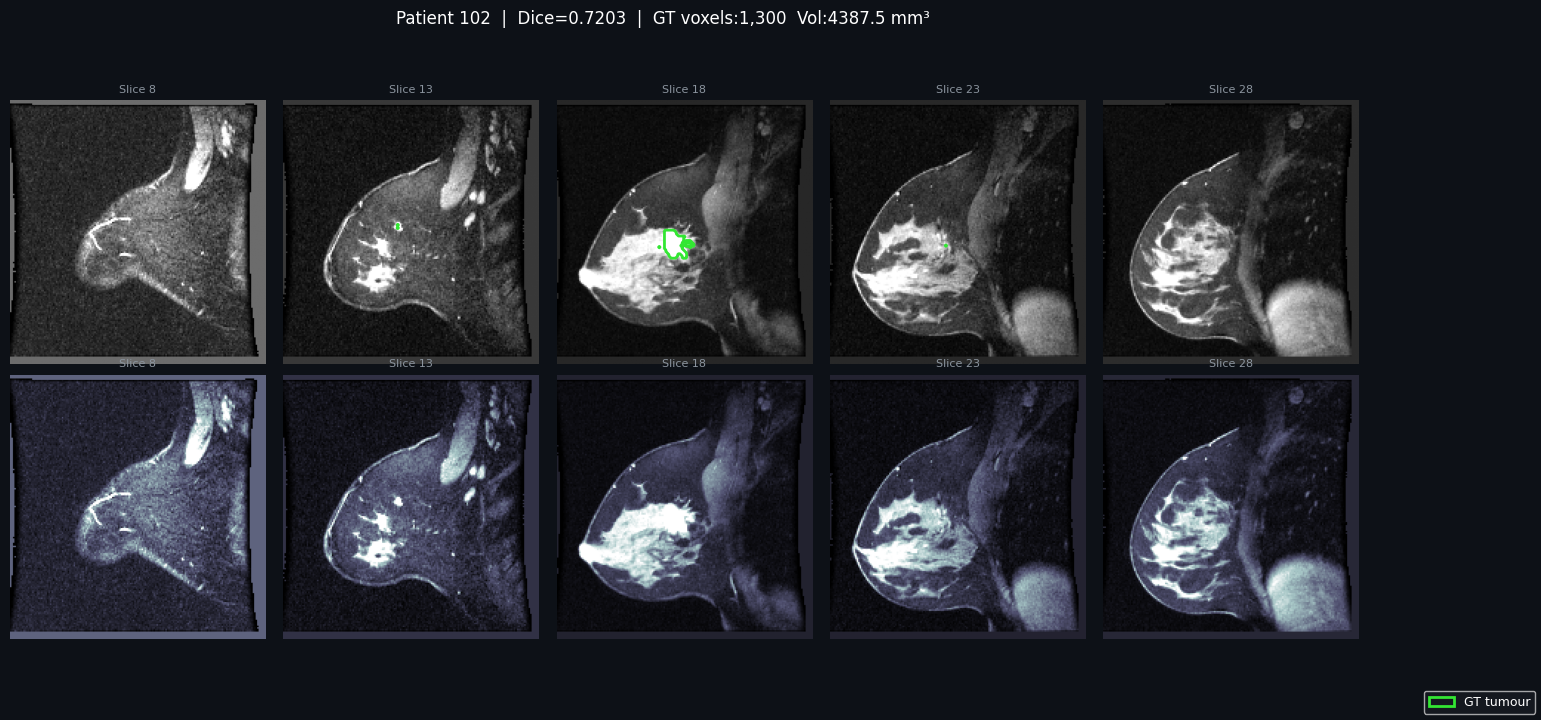

▶ (B) All 3 DCE channels with GT contour


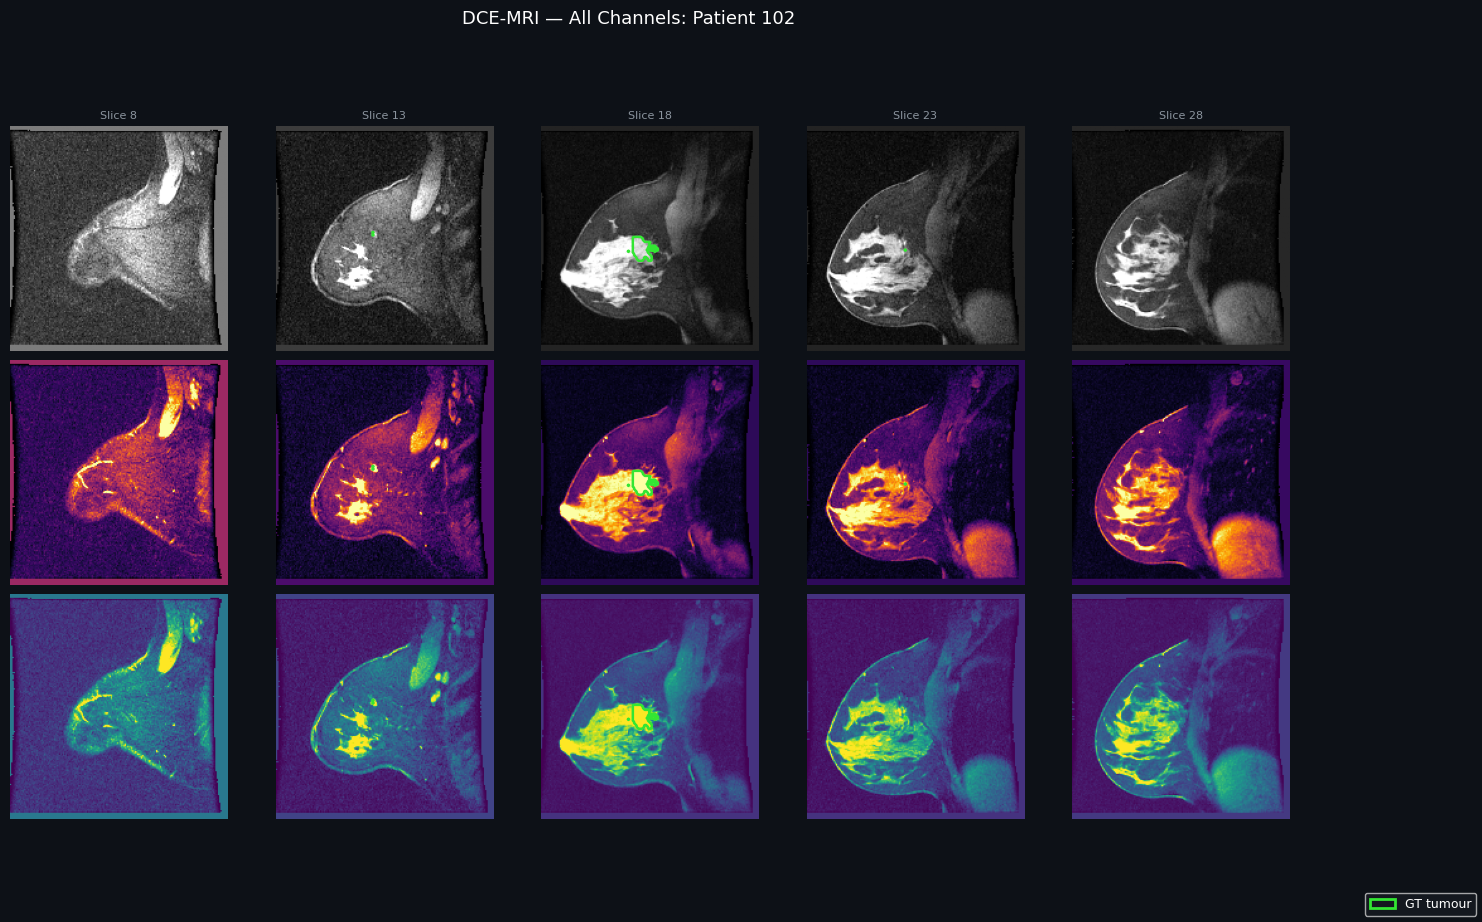

▶ (C) Max-Intensity Projection — 3 axes


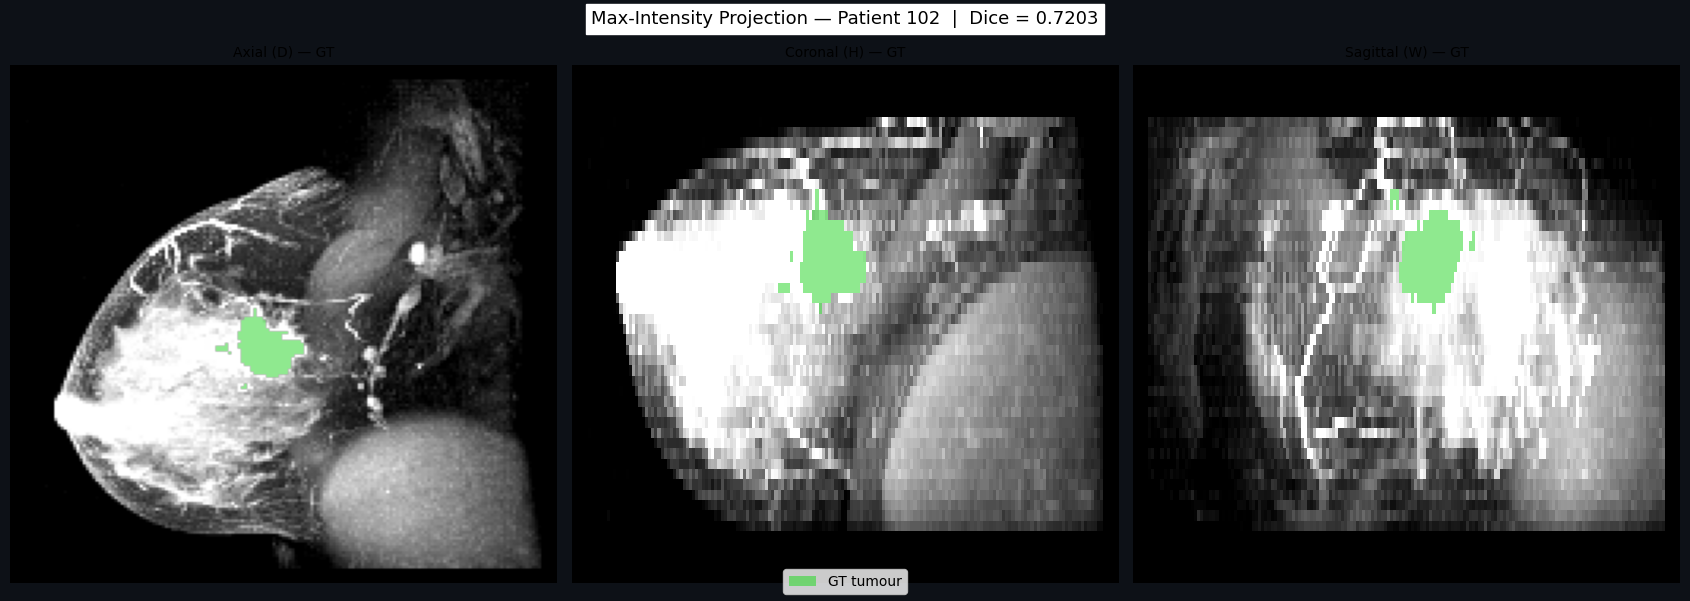

▶ (D) 3D volume render — filled projection


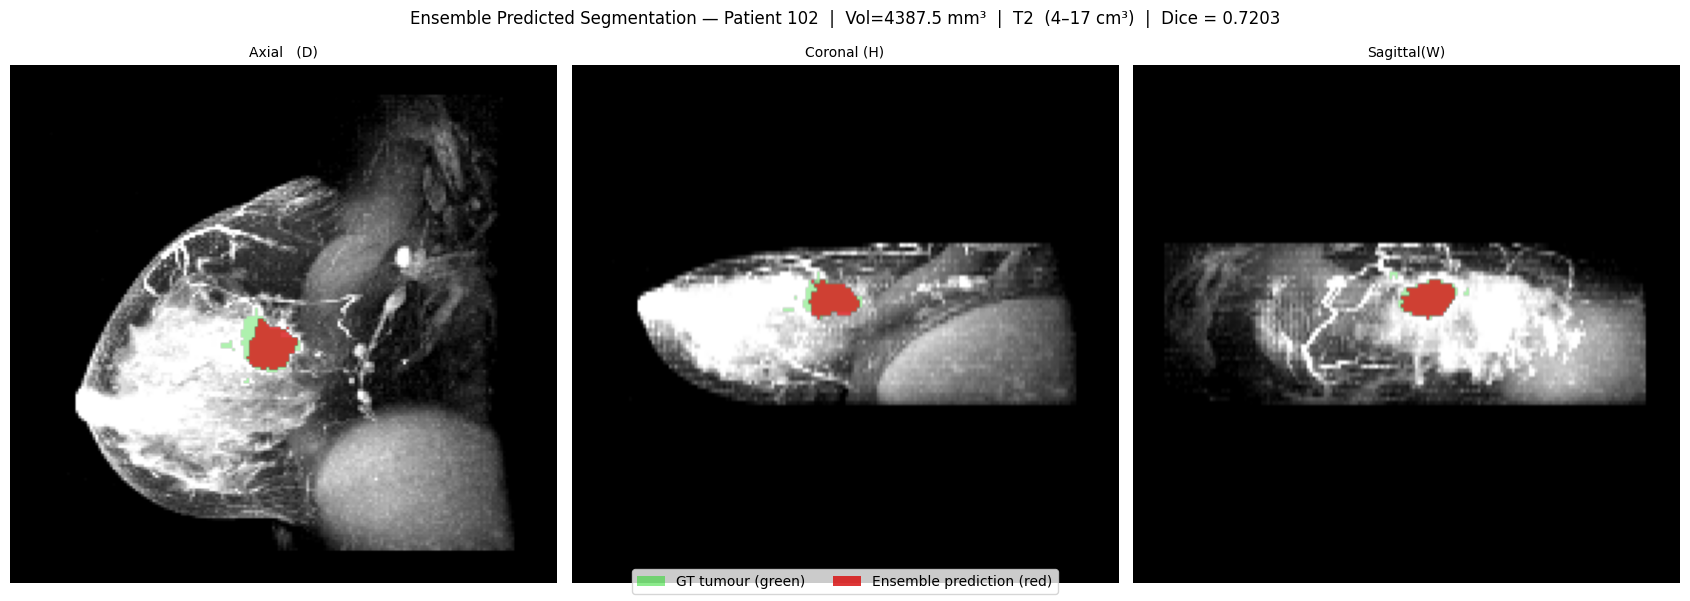

▶ (E) Feature panel — geometry · texture · kinetics · histogram · radar


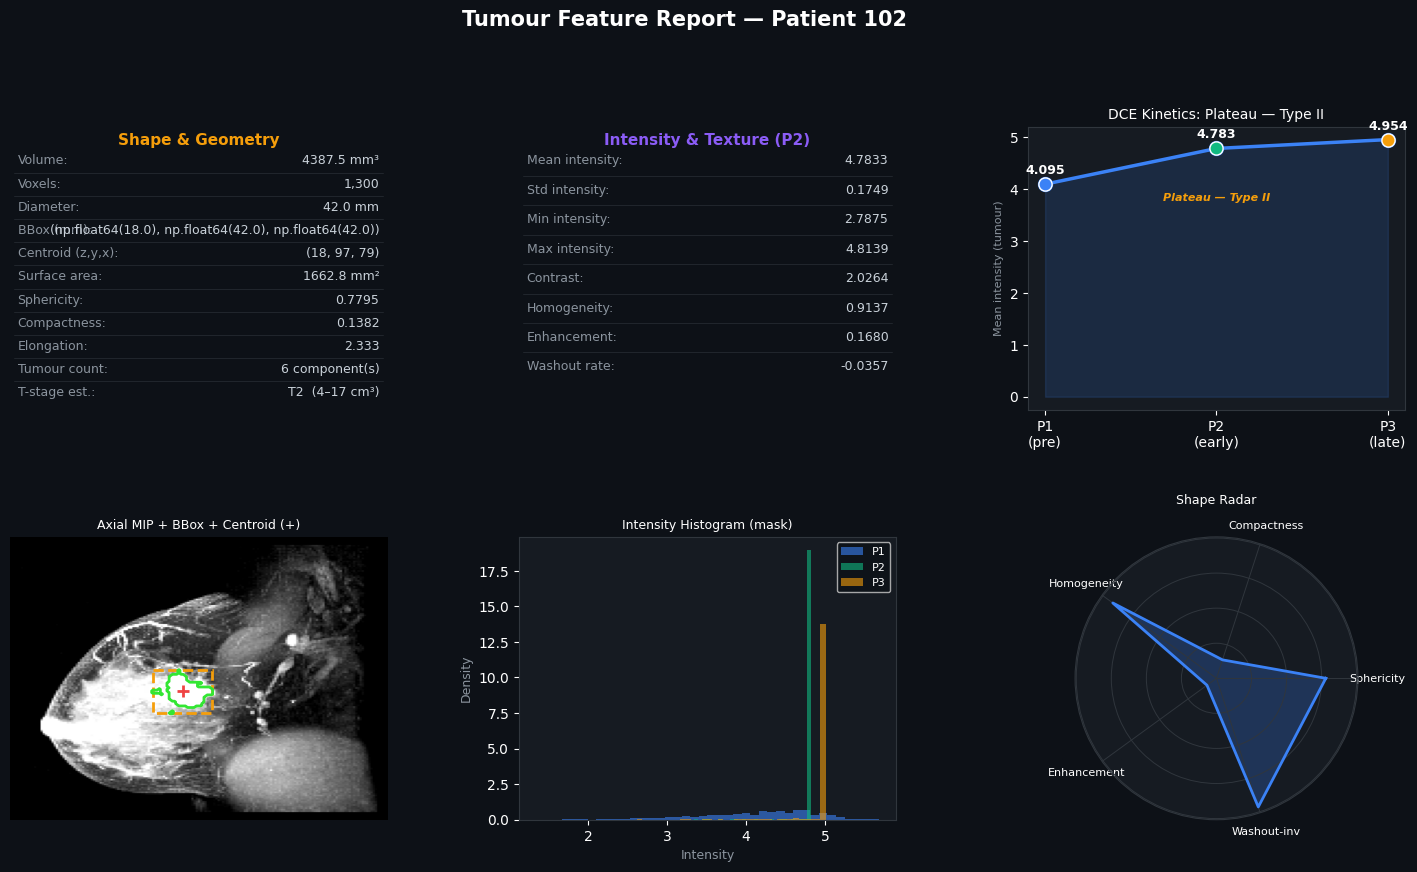

In [10]:
# Runs visualisation on the demo patient loaded in Cell 5.
# Re-run Cell 5 first if demo_result is None.
if demo_result is None:
    print("demo_result not found — run Cell 5 first.")
else:
    print(f"Visualising demo patient: {demo_result['patient_id']}\n")
    visualise_segmentation_complete(demo_result)


## 8. Specific or Random Patient Full Visualisation
Set `USE_RANDOM = True` to pick a random test patient, or specify `PATIENT_ID` directly.


Randomly selected: 145
Patient: 145  (class=malignant)

  Patient: 145
  Stage 1  : prob=1.0  → TUMOR DETECTED
  Volume   : 9561 mm³ (2833 voxels)  |  T2  (4–17 cm³)
  Centroid : (18, 109, 69)  |  BBox: (np.float64(37.5), np.float64(102.0), np.float64(69.0)) mm
  Surface  : 4412.2 mm²  |  Sphericity: 0.4938
  Tumours  : 31 component(s)  |  Elongation: 2.72
  Kinetic  : Plateau — Type II  |  Enhancement: 0.2651
  Texture  : mean=6.4061  std=0.613  contrast=3.957  homogeneity=0.8451
  Dice     : 0.6969
  Stage 3  : prob=0.833  → MALIGNANT
  Correct  : ✓  (true=MALIGNANT)

  SEGMENTATION — Patient 145
  Volume   : 9561.4 mm³  |  T2  (4–17 cm³)
  Centroid : (18, 109, 69)  |  BBox: (np.float64(37.5), np.float64(102.0), np.float64(69.0)) mm
  Surface  : 4412.2 mm²  |  Sphericity: 0.4938
  Tumours  : 31 component(s)  |  Elongation: 2.72
  Kinetic  : Plateau — Type II
  Texture  : mean=6.4061  std=0.613  contrast=3.957

▶ (A) Slice overlay — GT contour


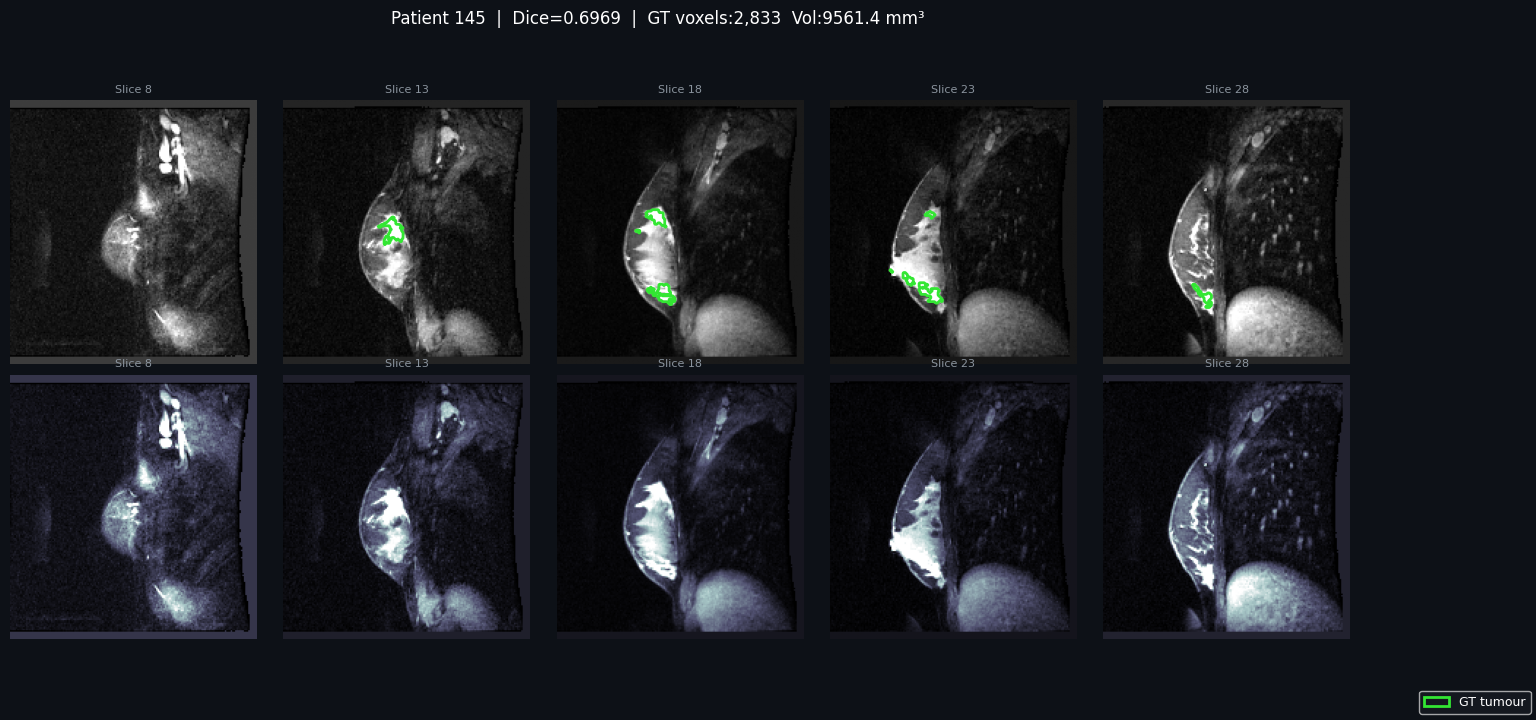

▶ (B) All 3 DCE channels with GT contour


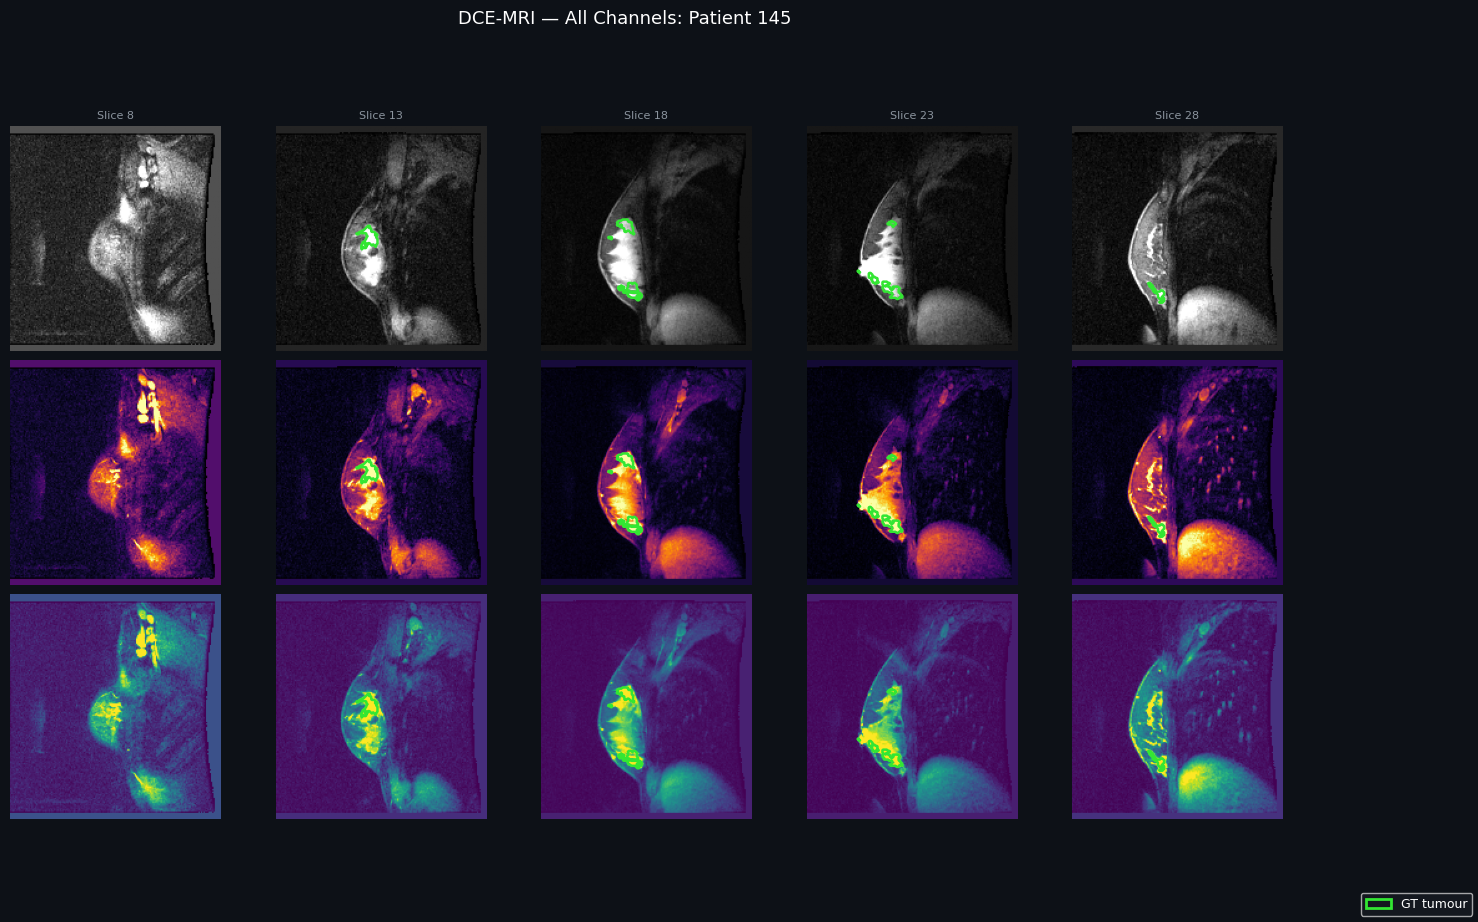

▶ (C) Max-Intensity Projection — 3 axes


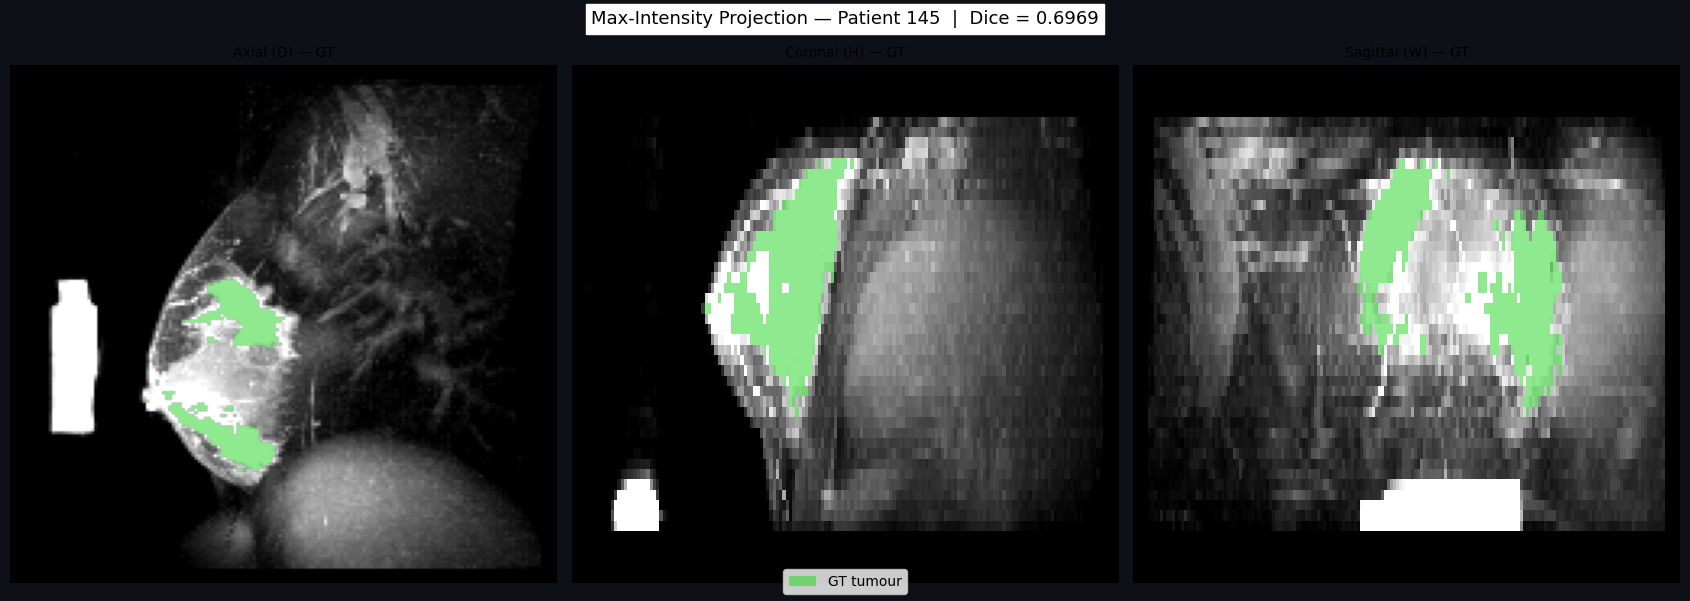

▶ (D) 3D volume render — filled projection


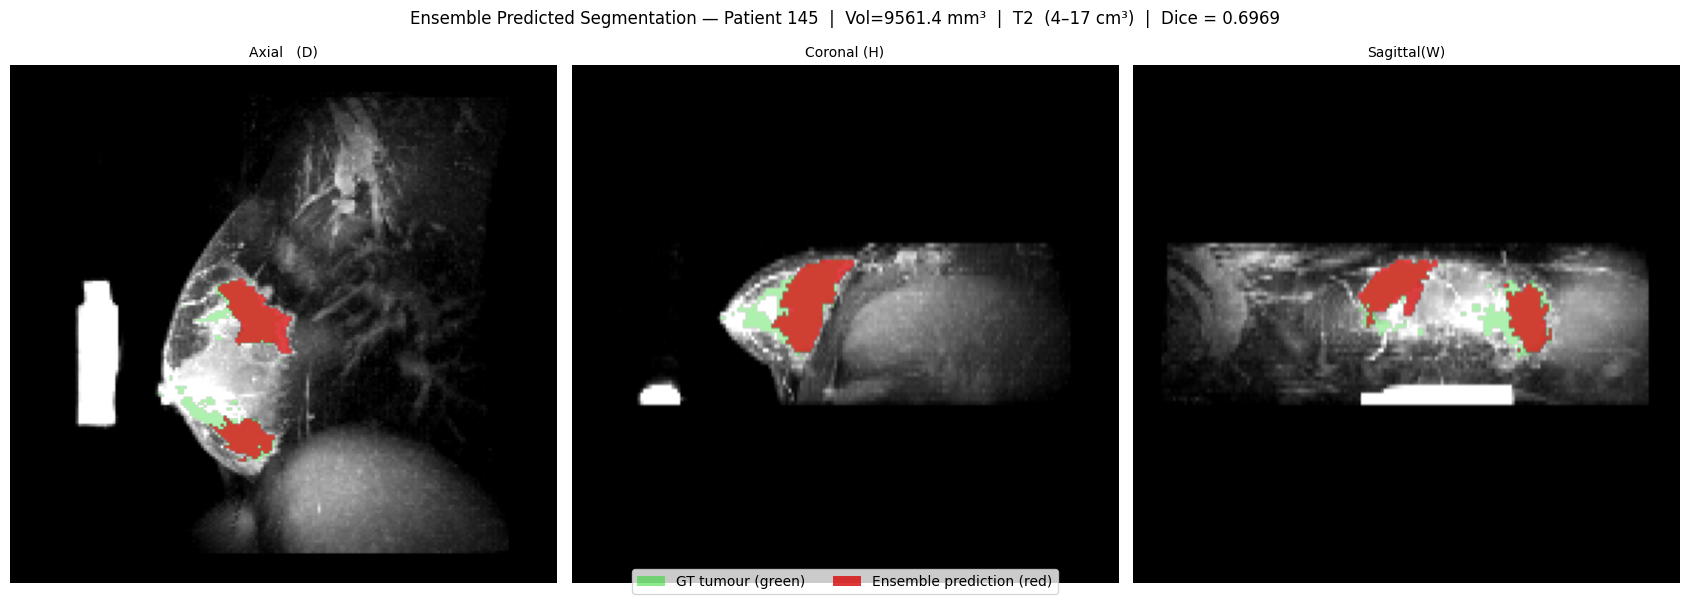

▶ (E) Feature panel — geometry · texture · kinetics · histogram · radar


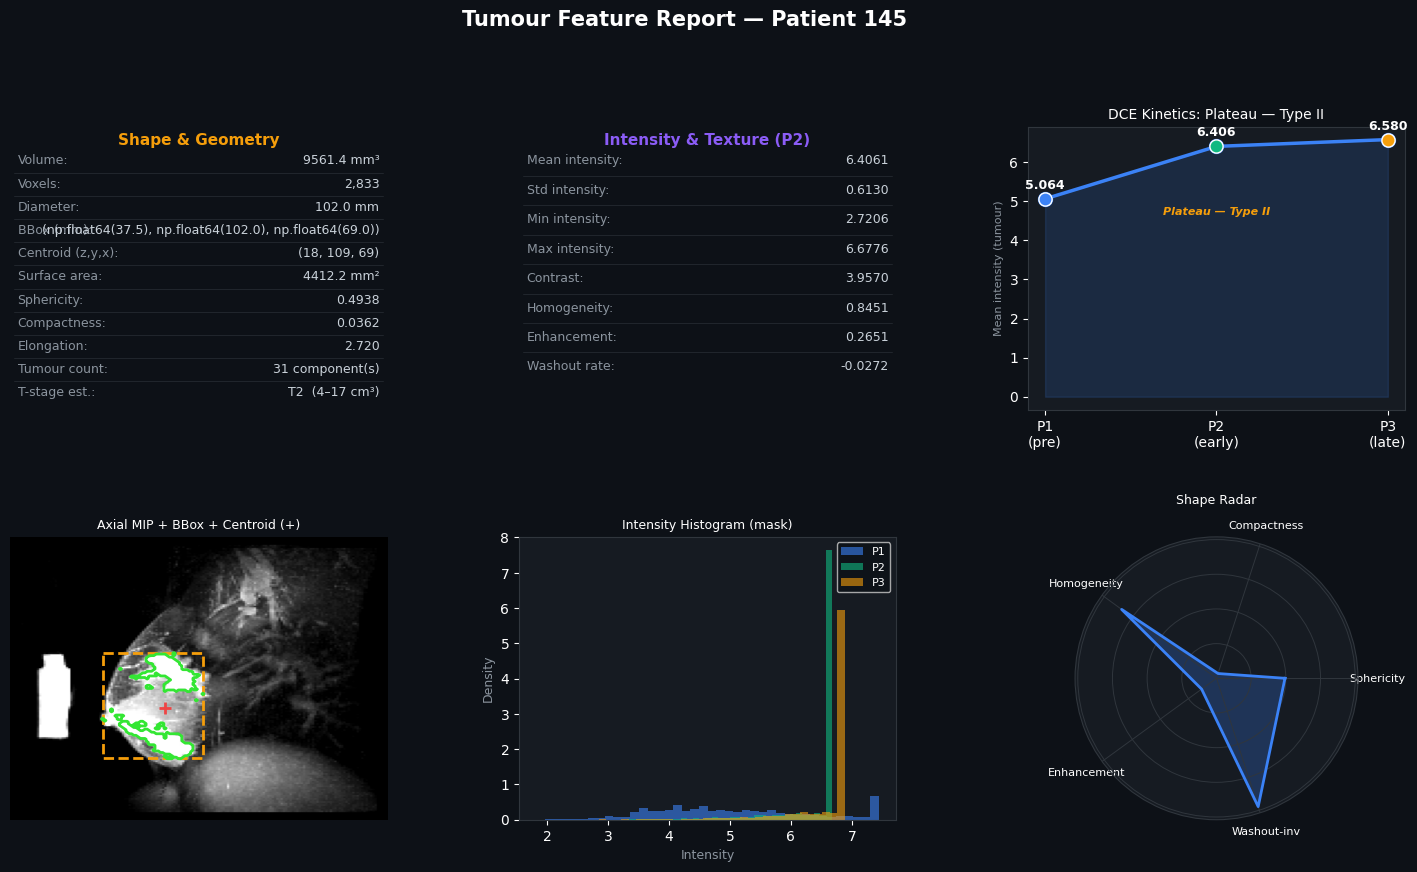

In [21]:
# ─── CONFIGURE ───────────────────────────────────────────────────
USE_RANDOM    = True          # True = random patient each run
PATIENT_CLASS = "malignant"    # "malignant" or "benign"
PATIENT_ID    = None           # e.g. "67" — None = first available
TRUE_S1       = 1              # 1=tumor, 0=no tumor (None=unknown)
TRUE_S3       = 1              # 1=malignant, 0=benign (None=unknown)
# ─────────────────────────────────────────────────────────────────

cls_dir = os.path.join(STAGE3_DATA, "test", PATIENT_CLASS)
if not os.path.isdir(cls_dir):
    print(f"Directory not found: {cls_dir}"); single_result = None
else:
    avail = [p for p in os.listdir(cls_dir)
         if os.path.isdir(os.path.join(cls_dir, p))]
    if USE_RANDOM and len(avail) > 0:
        PATIENT_ID = random.choice(avail)
        print(f"Randomly selected: {PATIENT_ID}")
    elif PATIENT_ID is None:
        PATIENT_ID = sorted(avail)[0]

    pdir = os.path.join(cls_dir, PATIENT_ID)
    print(f"Patient: {PATIENT_ID}  (class={PATIENT_CLASS})\n")
    single_result = run_full_pipeline(pdir, true_stage1_label=TRUE_S1,
                                       true_stage3_label=TRUE_S3, verbose=True)
    if single_result:
        visualise_segmentation_complete(single_result)


## 9. Batch Pipeline — All Stage 3 Test Patients

In [ ]:
all_results = []

for cls_name, true_s3 in [("malignant", 1), ("benign", 0)]:
    cls_dir = os.path.join(STAGE3_DATA, "test", cls_name)
    if not os.path.isdir(cls_dir): continue
    for pid in sorted(os.listdir(cls_dir)):
        pdir = os.path.join(cls_dir, pid)
        if not os.path.isfile(os.path.join(pdir, "image.npy")): continue
        res = run_full_pipeline(pdir,
                                true_stage1_label=1,
                                true_stage3_label=true_s3,
                                verbose=False)
        if res:
            # Drop raw img/pred_seg arrays before appending to save RAM
            # They're only needed for visualisation (single-patient cells)
            res_light = {k: v for k, v in res.items()
                         if k not in ("img", "lbl", "pred_seg")}
            all_results.append(res_light)
        # Clear GPU cache after every patient to prevent VRAM accumulation
        if device.type == "cuda":
            torch.cuda.empty_cache()

print(f"Processed {len(all_results)} test patients")

# Summary
s3_correct = sum(1 for r in all_results
                 if r["stage3_pred"] is not None and r["stage3_pred"] == r["stage3_label"])
n_mal_true = sum(1 for r in all_results if r["stage3_label"] == 1)
n_ben_true = sum(1 for r in all_results if r["stage3_label"] == 0)
fn_missed  = sum(1 for r in all_results if r["stage3_label"]==1 and r["stage3_pred"]==0)
fp_alarm   = sum(1 for r in all_results if r["stage3_label"]==0 and r["stage3_pred"]==1)

print(f"  Total patients : {len(all_results)}")
print(f"  Correct S3     : {s3_correct}/{len(all_results)} = {s3_correct/len(all_results):.1%}")
print(f"  Missed malignant (FN): {fn_missed}/{n_mal_true}")
print(f"  False alarms    (FP): {fp_alarm}/{n_ben_true}")

## 10. Per-Patient Results Table  *(V2 original)*

In [ ]:
if not all_results:
    print("No results to display")
else:
    # Sort by stage3 probability descending
    sorted_r = sorted(all_results,
                      key=lambda r: r["stage3_prob"] or 0, reverse=True)

    fig, ax = plt.subplots(figsize=(16, max(4, len(sorted_r)*0.28 + 1.5)),
                            facecolor="#0d1117")
    ax.set_facecolor("#0d1117"); ax.axis("off")

    cols = ["Patient", "True", "S3 Prob", "S3 Pred", "Correct",
            "Vol mm³", "Kinetic", "S1 Prob"]
    col_x = [0.01, 0.20, 0.29, 0.38, 0.47, 0.55, 0.65, 0.88]
    n     = len(sorted_r)
    row_h = 0.85 / (n + 1.5)

    # Header
    for c, cx in zip(cols, col_x):
        ax.text(cx, 0.97, c, transform=ax.transAxes,
                color="#8b949e", fontsize=8, fontweight="bold")
    ax.hlines(0.955, xmin=0, xmax=1, color="#30363d", lw=0.8, transform=ax.transAxes)

    for i, r in enumerate(sorted_r):
        y   = 0.955 - (i+1)*row_h
        true_str = "MAL" if r["stage3_label"]==1 else "BEN"
        pred_str = "MAL" if r["stage3_pred"]==1  else "BEN"
        ok       = r["stage3_pred"] == r["stage3_label"]
        ok_str   = "✓" if ok else "✗"
        row_c    = "#0d1117" if i%2==0 else "#0d1117"
        ok_c     = "#10b981" if ok else "#ef4444"
        s3p      = r["stage3_prob"] or 0
        s3_c     = "#ef4444" if s3p >= 0.5 else "#3b82f6"
        vals = [r["patient_id"][:20], true_str,
                f"{s3p:.3f}", pred_str, ok_str,
                f"{r['tumor_mm3']:.0f}",
                r["kinetic_type"][:14],
                f"{r['stage1_prob']:.3f}" if r["stage1_prob"] is not None else "—"]
        colors = ["#c9d1d9","#c9d1d9",s3_c,s3_c,ok_c,"#c9d1d9","#c9d1d9","#c9d1d9"]

        for v, cx, vc in zip(vals, col_x, colors):
            ax.text(cx, y, v, transform=ax.transAxes,
                    color=vc, fontsize=7, va="center")

    ax.set_title("Per-Patient Pipeline Results (sorted by S3 malignancy probability)",
                 color="white", fontsize=12, pad=10)
    plt.savefig("pipeline_patient_table.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()

## 11. Per-Patient Results Table — Extended  *(all tumour metrics)*

In [ ]:
if not all_results:
    print("No results — run Cell 8 first")
else:
    sorted_r = sorted(all_results, key=lambda r: r["stage3_prob"] or 0, reverse=True)

    cols = ["Patient","True","S3Prob","S3Pred","OK",
            "Vol mm³","Diam mm","Sph","Comp","SurfA mm²",
            "Tumours","T-stage","Kinetic","Enhance","Washout",
            "Mean I","Std I","Contrast","S1Prob"]
    col_x = [0.00,0.10,0.15,0.21,0.26,
              0.30,0.36,0.41,0.46,0.51,
              0.57,0.62,0.69,0.76,0.81,
              0.85,0.89,0.93,0.97]

    row_h = 0.84 / (len(sorted_r) + 1.5)
    fig_h  = max(6, len(sorted_r)*0.32 + 2.5)
    fig, ax = plt.subplots(figsize=(28, fig_h), facecolor=BG)
    ax.set_facecolor(BG); ax.axis("off")

    for c, cx in zip(cols, col_x):
        ax.text(cx, 0.97, c, transform=ax.transAxes,
                color=MUTED, fontsize=6.5, fontweight="bold")
    ax.hlines(0.955, xmin=0, xmax=1, color=BORDER, lw=0.8, transform=ax.transAxes)

    for i, r in enumerate(sorted_r):
        y   = 0.955 - (i+1)*row_h
        f   = r.get("feat",{})
        s3p = r["stage3_prob"] or 0
        ok  = (r["stage3_pred"] == r["stage3_label"])
        t3  = "MAL" if r["stage3_label"]==1 else "BEN"
        p3  = "MAL" if r["stage3_pred"]==1  else "BEN"
        ok_c= GREEN if ok else RED
        s3c = RED if s3p>=0.5 else BLUE
        kin = f.get("kinetic_type","—")
        kin_c = RED if "III" in kin else AMBER if "II" in kin else GREEN

        vals = [
            r["patient_id"][:12],
            t3, f"{s3p:.3f}", p3, "✓" if ok else "✗",
            f"{f.get('volume_mm3',0):.0f}",
            f"{f.get('diameter_mm',0):.1f}",
            f"{f.get('sphericity',0):.3f}",
            f"{f.get('compactness',0):.3f}",
            f"{f.get('surface_area_mm2',0):.0f}",
            str(f.get("tumour_count",0)),
            f.get("t_stage","—")[:9],
            kin[:9],
            f"{f.get('enhancement_ratio',0):.3f}",
            f"{f.get('washout_rate',0):.3f}",
            f"{f.get('mean_intensity',0):.3f}",
            f"{f.get('std_intensity',0):.3f}",
            f"{f.get('contrast',0):.3f}",
            f"{r.get('stage1_prob',0) or 0:.3f}",
        ]
        colors = [TEXT, TEXT, s3c, s3c, ok_c,
                  TEXT,TEXT,TEXT,TEXT,TEXT,
                  RED if f.get("tumour_count",0)>1 else TEXT,
                  AMBER, kin_c, TEXT,TEXT,
                  TEXT,TEXT,TEXT, TEXT]

        for v, cx, vc in zip(vals, col_x, colors):
            ax.text(cx, y, v, transform=ax.transAxes,
                    color=vc, fontsize=6.2, va="center")
        if i%2==0:
            ax.axhspan(y-row_h*0.45, y+row_h*0.55, xmin=0, xmax=1,
                       facecolor="#ffffff06", transform=ax.transAxes)

    ax.set_title("Per-Patient Results — All Tumour Metrics (sorted by S3 probability)",
                 color="white", fontsize=11, pad=8)
    plt.savefig("patient_table_full.png", dpi=160, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"Table saved → patient_table_full.png")


## 12. Tumour Feature Distributions — Malignant vs Benign

In [ ]:
if not all_results:
    print("No results — run Cell 8 first")
else:
    mal_r = [r for r in all_results if r.get("stage3_label")==1 and r.get("feat",{}).get("voxels",0)>0]
    ben_r = [r for r in all_results if r.get("stage3_label")==0 and r.get("feat",{}).get("voxels",0)>0]

    def fv(results, key): return [r["feat"].get(key,0) for r in results]

    fig, axes = plt.subplots(3, 4, figsize=(22, 14), facecolor=BG)
    fig.suptitle("Tumour Feature Distributions — Malignant vs Benign (test set)",
                 color="white", fontsize=14, y=1.01)

    def hist_pair(ax, mal_v, ben_v, xlabel, title, bins=18, log=False):
        ax.set_facecolor(CARD)
        if mal_v: ax.hist(mal_v, bins=bins, color=RED,   alpha=0.65, label="Malignant",
                          density=True, log=log)
        if ben_v: ax.hist(ben_v, bins=bins, color=GREEN, alpha=0.65, label="Benign",
                          density=True, log=log)
        if mal_v: ax.axvline(np.median(mal_v), color=RED,   lw=1.5, linestyle="--", alpha=0.8)
        if ben_v: ax.axvline(np.median(ben_v), color=GREEN, lw=1.5, linestyle="--", alpha=0.8)
        ax.set_xlabel(xlabel, color=MUTED, fontsize=8)
        ax.set_ylabel("Density", color=MUTED, fontsize=8)
        ax.set_title(title, color="white", fontsize=10)
        ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
        ax.legend(facecolor=BG, labelcolor="white", fontsize=7)

    hist_pair(axes[0,0], fv(mal_r,"volume_mm3"),      fv(ben_r,"volume_mm3"),
              "Volume (mm³)", "Tumour Volume", log=True)
    hist_pair(axes[0,1], fv(mal_r,"diameter_mm"),      fv(ben_r,"diameter_mm"),
              "Max diameter (mm)", "Diameter")
    hist_pair(axes[0,2], fv(mal_r,"surface_area_mm2"), fv(ben_r,"surface_area_mm2"),
              "Surface area (mm²)", "Surface Area", log=True)
    hist_pair(axes[0,3], fv(mal_r,"sphericity"),        fv(ben_r,"sphericity"),
              "Sphericity", "Sphericity", bins=14)

    hist_pair(axes[1,0], fv(mal_r,"compactness"),       fv(ben_r,"compactness"),
              "Compactness", "Compactness")
    hist_pair(axes[1,1], fv(mal_r,"elongation"),        fv(ben_r,"elongation"),
              "Elongation", "Elongation")
    hist_pair(axes[1,2], fv(mal_r,"enhancement_ratio"), fv(ben_r,"enhancement_ratio"),
              "Enhancement ratio", "DCE Enhancement")
    hist_pair(axes[1,3], fv(mal_r,"washout_rate"),      fv(ben_r,"washout_rate"),
              "Washout rate", "DCE Washout")

    hist_pair(axes[2,0], fv(mal_r,"mean_intensity"),    fv(ben_r,"mean_intensity"),
              "Mean intensity (P2)", "Mean Intensity")
    hist_pair(axes[2,1], fv(mal_r,"contrast"),          fv(ben_r,"contrast"),
              "Contrast (max-min)", "Texture Contrast")
    hist_pair(axes[2,2], fv(mal_r,"homogeneity"),       fv(ben_r,"homogeneity"),
              "Homogeneity", "Texture Homogeneity")

    # Kinetic type donut
    from collections import Counter
    ax_k = axes[2,3]; ax_k.set_facecolor(CARD)
    all_kin = [r["feat"].get("kinetic_type","?").split("—")[0].strip()
               for r in all_results if r.get("feat",{}).get("voxels",0)>0]
    kin_cnt = Counter(all_kin)
    kin_col = [RED, AMBER, BLUE]
    wedges, txts, atxts = ax_k.pie(
        list(kin_cnt.values()), labels=list(kin_cnt.keys()),
        colors=kin_col[:len(kin_cnt)], autopct="%1.0f%%",
        textprops={"color":"white","fontsize":9},
        wedgeprops={"width":0.55, "edgecolor":BG, "linewidth":1.5}
    )
    ax_k.set_title("DCE Kinetic Types", color="white", fontsize=10)

    plt.tight_layout()
    plt.savefig("tumour_features_distribution.png", dpi=130,
                bbox_inches="tight", facecolor=BG)
    plt.show()
    print("Feature distribution saved → tumour_features_distribution.png")


## 13. Project Summary Card

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117"); ax.axis("off")

card = plt.Rectangle((0.01, 0.02), 0.98, 0.96,
                      transform=ax.transAxes, facecolor="#161b22",
                      edgecolor="#30363d", linewidth=2, clip_on=False)
ax.add_patch(card)

ax.text(0.5, 0.92, "Breast Tumor AI — Complete Pipeline Results",
        transform=ax.transAxes, ha="center", color="white",
        fontsize=16, fontweight="bold")
ax.text(0.5, 0.86, "Stage 1 Detection  →  Ensemble Segmentation  →  Stage 3 Classification",
        transform=ax.transAxes, ha="center", color="#8b949e", fontsize=11)

# Divider line
ax.hlines(0.82, xmin=0.03, xmax=0.97, color="#30363d", lw=1, transform=ax.transAxes)

# Stage 1
ax.text(0.12, 0.76, "Stage 1", transform=ax.transAxes,
        color="#3b82f6", fontsize=13, fontweight="bold", ha="center")
ax.text(0.12, 0.71, "Tumor Detection", transform=ax.transAxes,
        color="#8b949e", fontsize=9, ha="center")
try:
    ax.text(0.12, 0.63, f"AUC\n{auc1:.4f}", transform=ax.transAxes,
            color="#10b981", fontsize=18, fontweight="bold", ha="center")
    ax.text(0.12, 0.50, f"Sens={sens1:.3f}\nSpec={spec1:.3f}\nAcc={acc1:.3f}",
            transform=ax.transAxes, color="#c9d1d9", fontsize=10, ha="center")
    ax.text(0.12, 0.38, f"3D ResNet18+CBAM",
            transform=ax.transAxes, color="#6b7280", fontsize=8, ha="center")
except NameError:
    ax.text(0.12, 0.60, "not run", transform=ax.transAxes, color="#6b7280", ha="center")

# Arrow
ax.annotate("", xy=(0.30, 0.60), xytext=(0.22, 0.60),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="#30363d", lw=2))

# Segmentation
ax.text(0.50, 0.76, "Segmentation", transform=ax.transAxes,
        color="#f59e0b", fontsize=13, fontweight="bold", ha="center")
ax.text(0.50, 0.71, "Tumor Mask + Features", transform=ax.transAxes,
        color="#8b949e", fontsize=9, ha="center")
ax.text(0.50, 0.63, "Dice\n~0.73", transform=ax.transAxes,
        color="#10b981", fontsize=18, fontweight="bold", ha="center")
ax.text(0.50, 0.50, f"MONAI + DynUNet + 2D\nEnsemble (Combination C)",
        transform=ax.transAxes, color="#c9d1d9", fontsize=10, ha="center")
ax.text(0.50, 0.40, "Volume mm³  |  DCE Kinetics",
        transform=ax.transAxes, color="#6b7280", fontsize=8, ha="center")

# Arrow
ax.annotate("", xy=(0.68, 0.60), xytext=(0.60, 0.60),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="#30363d", lw=2))

# Stage 3
ax.text(0.85, 0.76, "Stage 3", transform=ax.transAxes,
        color="#ef4444", fontsize=13, fontweight="bold", ha="center")
ax.text(0.85, 0.71, "Benign vs Malignant", transform=ax.transAxes,
        color="#8b949e", fontsize=9, ha="center")
try:
    ax.text(0.85, 0.63, f"AUC\n{auc3:.4f}", transform=ax.transAxes,
            color="#10b981", fontsize=18, fontweight="bold", ha="center")
    ax.text(0.85, 0.50, f"Sens={sens3:.3f}\nSpec={spec3:.3f}\nAcc={acc3:.3f}",
            transform=ax.transAxes, color="#c9d1d9", fontsize=10, ha="center")
    ax.text(0.85, 0.38, "3D EfficientNet-B0",
            transform=ax.transAxes, color="#6b7280", fontsize=8, ha="center")
except NameError:
    ax.text(0.85, 0.60, "not run", transform=ax.transAxes, color="#6b7280", ha="center")

# Bottom status
try:
    combined_ok = (auc1 >= 0.85) and (auc3 >= 0.85)
    status_t = "COMPLETE — ALL STAGES PRODUCTION READY" if combined_ok else "COMPLETE — RESULTS STRONG"
    status_c = "#10b981" if combined_ok else "#f59e0b"
except NameError:
    status_t = "COMPLETE"; status_c = "#f59e0b"

ax.text(0.5, 0.22, status_t, transform=ax.transAxes, ha="center",
        color=status_c, fontsize=15, fontweight="bold")
ax.text(0.5, 0.13, f"Dataset: 219 patients (segmentation)  |  516 patients (classification)",
        transform=ax.transAxes, ha="center", color="#6b7280", fontsize=9)

plt.savefig("pipeline_summary_card.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("  Complete pipeline notebook done.")